# Electricity Consumption in Spain

## Data Analysis

## Setup

We use Polars because Table A is large. Lazy Parquet scanning allows us to work with the data without loading all 16 million records into memory at once.

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path
import polars as pl

In [2]:
PROJECT_ROOT = Path.cwd().parent

A_PATH = PROJECT_ROOT / "data" / "A_cleaned.parquet"

if not A_PATH.exists():
    raise FileNotFoundError(
        f"Could not find Table A at: {A_PATH}\n"
        "Make sure the notebook is inside the EDA folder."
    )

A = pl.scan_parquet(str(A_PATH))
A.head().collect()

CUSTOMER_ID,DATE,ACTIVE_H1,REACTIVE_H1,ACTIVE_H2,REACTIVE_H2,ACTIVE_H3,REACTIVE_H3,ACTIVE_H4,REACTIVE_H4,ACTIVE_H5,REACTIVE_H5,ACTIVE_H6,REACTIVE_H6,ACTIVE_H7,REACTIVE_H7,ACTIVE_H8,REACTIVE_H8,ACTIVE_H9,REACTIVE_H9,ACTIVE_H10,REACTIVE_H10,ACTIVE_H11,REACTIVE_H11,ACTIVE_H12,REACTIVE_H12,ACTIVE_H13,REACTIVE_H13,ACTIVE_H14,REACTIVE_H14,ACTIVE_H15,REACTIVE_H15,ACTIVE_H16,REACTIVE_H16,ACTIVE_H17,REACTIVE_H17,ACTIVE_H18,REACTIVE_H18,ACTIVE_H19,REACTIVE_H19,ACTIVE_H20,REACTIVE_H20,ACTIVE_H21,REACTIVE_H21,ACTIVE_H22,REACTIVE_H22,ACTIVE_H23,REACTIVE_H23,ACTIVE_H24,REACTIVE_H24,ACTIVE_H25,REACTIVE_H25,MUNICIPALITY,SUPPLY_REGISTRATION_PERIOD,GAS_DISTRIBUTION_PROBABILITY,CUSTOMER_TYPE,ELECTRICITY_PRODUCT,MARKET
i64,date,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,str,str,f32,cat,cat,cat
67072,2015-07-23,194,1,148,0,108,1,109,2,107,0,108,0,115,6,232,64,216,34,357,8,2943,603,1624,347,2142,377,2570,491,1994,391,8192906,188,104,1,101,0,141,0,344,46,3303,853,776,179,2866,649,2041,453,0,0,"""CASTELLON DE LA PLANA""","""Q12013""",null,"""T1""","""P17""","""M2"""
11933,2015-01-11,139194,0,129014,0,119181,0,112334,0,110510,0,115472,0,116996,0,113849,0,82597,0,69862,0,73648,0,67530,0,69331,0,69631,0,68792,0,61337,0,58759,0,61631,0,112805,0,146865,0,150367,0,154261,0,135836,0,141930,0,0,0,"""MADRID""",null,null,"""T2""","""P72""","""M2"""
10745,2015-02-24,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,51417,0,137113,0,137113,0,154252,0,137113,0,154252,0,137113,0,137113,0,137113,0,137113,0,154252,0,0,0,"""MADRID""","""Q32013""",null,"""T2""","""P13""","""M2"""
10618,2015-02-28,45143,0,36499,0,31298,0,28421,0,27124,0,27113,0,28427,0,31998,0,39622,0,50823,0,60310,0,64333,0,65918,0,67494,0,64888,0,59344,0,55623,0,54511,0,57982,0,63571,0,67528,0,68476,0,63079,0,54286,0,0,0,"""MADRID""","""Q22009""",null,"""T2""","""P30""","""M2"""
10618,2015-03-01,42833,0,35405,0,31139,0,28567,0,27026,0,26621,0,27120,0,29711,0,34712,0,43900,0,51524,0,56005,0,57116,0,58000,0,57917,0,51760,0,49078,0,48231,0,50936,0,59501,0,67801,0,68563,0,59820,0,49401,0,0,0,"""MADRID""","""Q22009""",null,"""T2""","""P30""","""M2"""


## Active and Reactive electricity consumption columns

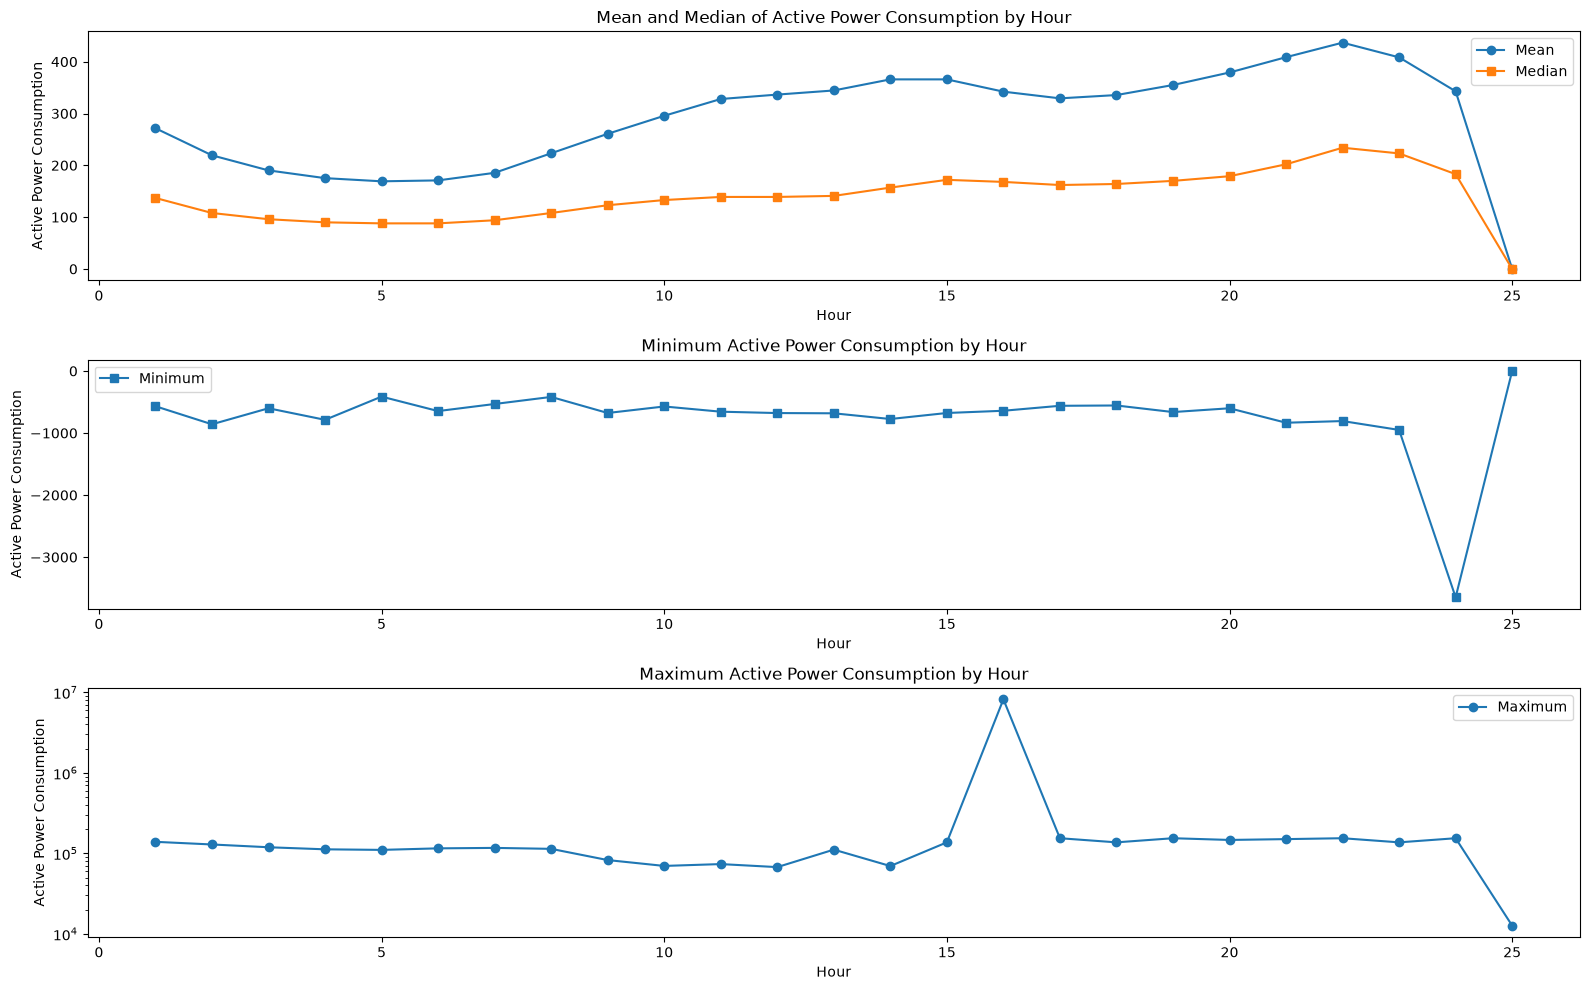

In [3]:
active_cols = [f"ACTIVE_H{i}" for i in range(1, 26)]
active_stats = []
for c in active_cols:
    row = (
        A.select([
            pl.col(c).min().alias("minimum"),
            pl.col(c).max().alias("maximum"),
            pl.col(c).mean().alias("mean"),
            pl.col(c).median().alias("median"),
        ])
        .collect()
        .row(0)
    )
    active_stats.append({
        "column": c,
        "minimum": row[0],
        "maximum": row[1],
        "mean": row[2],
        "median": row[3],
    })
active_stats_df = pl.DataFrame(active_stats)

time_position = list(range(1, 26))

plt.figure(figsize=(16, 10))

plt.subplot(3,1,1)
plt.plot(time_position, active_stats_df["mean"], marker='o', label='Mean')
plt.plot(time_position, active_stats_df["median"], marker='s', label='Median')
plt.title("Mean and Median of Active Power Consumption by Hour")
plt.xlabel("Hour")
plt.ylabel("Active Power Consumption")
plt.legend()

plt.subplot(3,1,2)
plt.plot(time_position, active_stats_df["minimum"], marker='s', label='Minimum')
plt.title("Minimum Active Power Consumption by Hour")
plt.xlabel("Hour")
plt.ylabel("Active Power Consumption")
plt.legend()

plt.subplot(3,1,3)
plt.plot(time_position, active_stats_df["maximum"], marker='o', label='Maximum')
plt.yscale('log')
plt.title("Maximum Active Power Consumption by Hour")
plt.xlabel("Hour")
plt.ylabel("Active Power Consumption")
plt.legend()

plt.tight_layout()
plt.show()

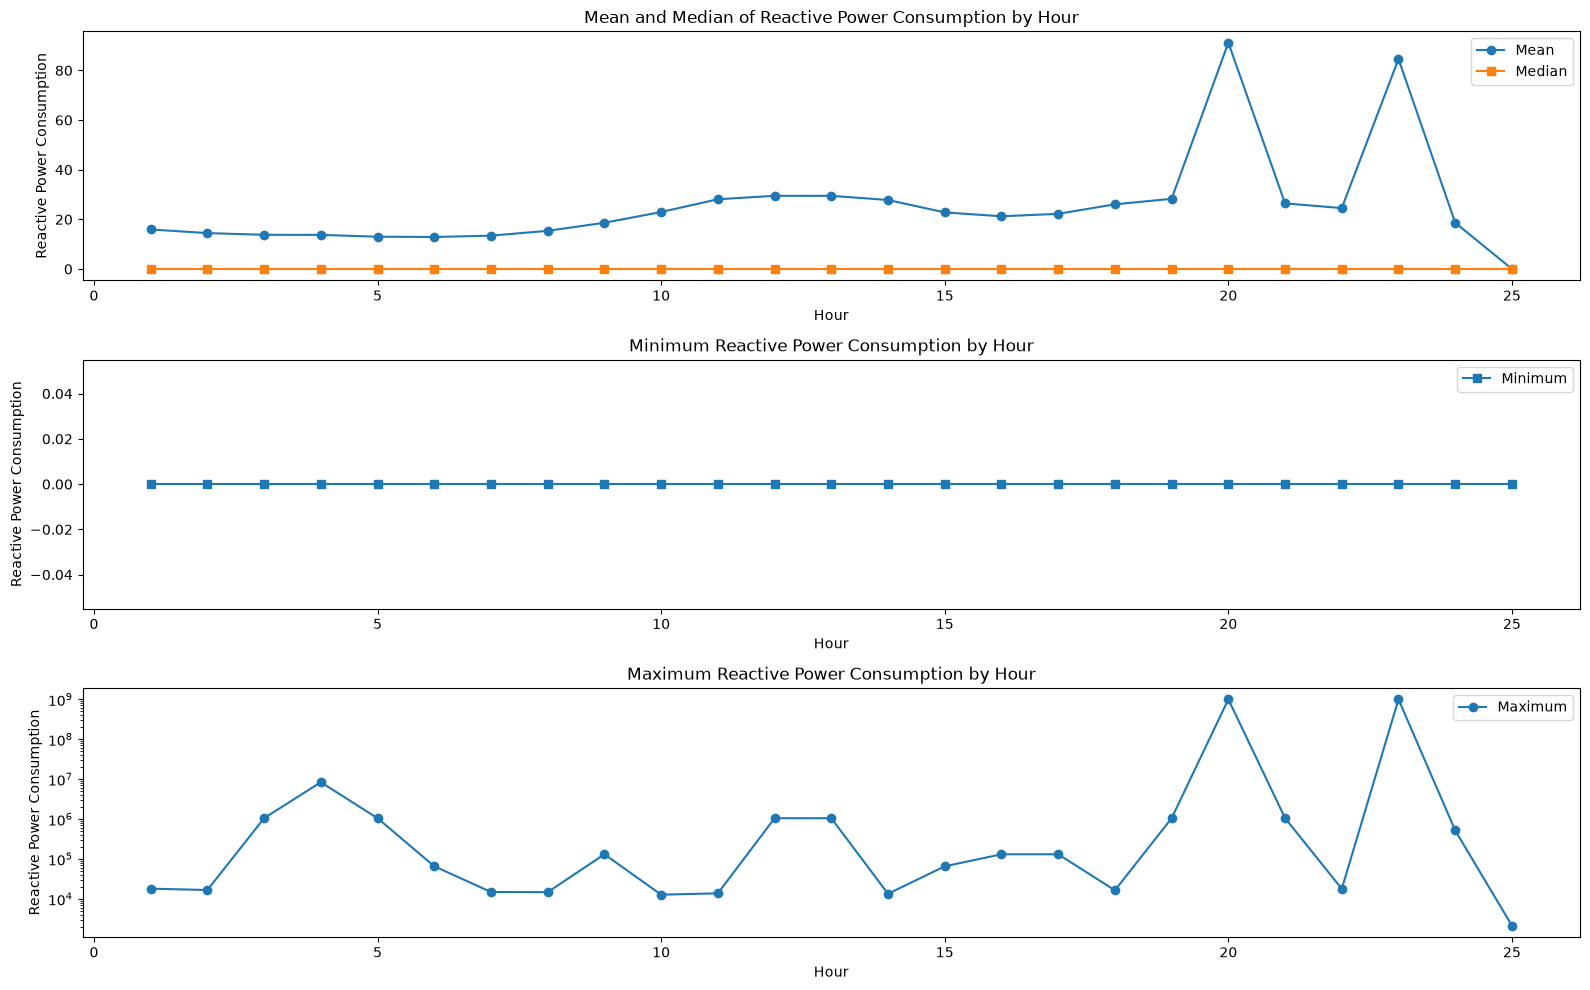

In [4]:
reactive_cols = [f"REACTIVE_H{i}" for i in range(1, 26)]
reactive_stats = []

for c in reactive_cols:
    row = (
        A.select([
            pl.col(c).min().alias("minimum"),
            pl.col(c).max().alias("maximum"),
            pl.col(c).mean().alias("mean"),
            pl.col(c).median().alias("median"),
        ])
        .collect()
        .row(0)
    )

    reactive_stats.append({
        "column": c,
        "minimum": row[0],
        "maximum": row[1],
        "mean": row[2],
        "median": row[3],
    })

reactive_stats_df = pl.DataFrame(reactive_stats)

time_position = list(range(1, 26))

plt.figure(figsize=(16, 10))

plt.subplot(3,1,1)
plt.plot(time_position, reactive_stats_df["mean"], marker='o', label='Mean')
plt.plot(time_position, reactive_stats_df["median"], marker='s', label='Median')
plt.title("Mean and Median of Reactive Power Consumption by Hour")
plt.xlabel("Hour")
plt.ylabel("Reactive Power Consumption")
plt.legend()

plt.subplot(3,1,2)
plt.plot(time_position, reactive_stats_df["minimum"], marker='s', label='Minimum')
plt.title("Minimum Reactive Power Consumption by Hour")
plt.xlabel("Hour")
plt.ylabel("Reactive Power Consumption")
plt.legend()

plt.subplot(3,1,3)
plt.plot(time_position, reactive_stats_df["maximum"], marker='o', label='Maximum')
plt.yscale('log')
plt.title("Maximum Reactive Power Consumption by Hour")
plt.xlabel("Hour")
plt.ylabel("Reactive Power Consumption")
plt.legend()

plt.tight_layout()
plt.show()

## Power Factor Analysis

In [5]:
A = A.with_columns([
    pl.sum_horizontal([pl.col(c).cast(pl.Int64) for c in active_cols]).alias("DAILY_ACTIVE_CONSUMPTION"),
    pl.sum_horizontal([pl.col(c).cast(pl.Int64) for c in reactive_cols]).alias("DAILY_REACTIVE_CONSUMPTION")
])

A = A.with_columns([
    (pl.col("DAILY_ACTIVE_CONSUMPTION").pow(2) + pl.col("DAILY_REACTIVE_CONSUMPTION").pow(2))
    .sqrt()
    .alias("APPARENT_ENERGY"),
    
    pl.when(
        (pl.col("DAILY_ACTIVE_CONSUMPTION").pow(2) + pl.col("DAILY_REACTIVE_CONSUMPTION").pow(2)).sqrt() == 0
    )
    .then(None)
    .otherwise(pl.col("DAILY_ACTIVE_CONSUMPTION") / (pl.col("DAILY_ACTIVE_CONSUMPTION").pow(2) + pl.col("DAILY_REACTIVE_CONSUMPTION").pow(2)).sqrt())
    .alias("POWER_FACTOR")
])

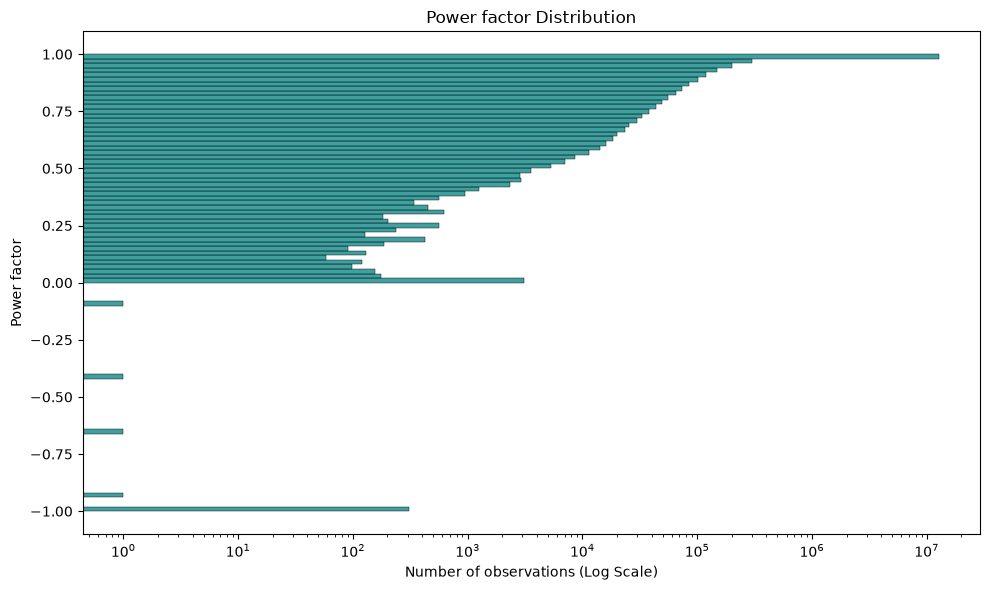

In [6]:
values = (
    A.select("POWER_FACTOR").collect().to_series().to_numpy()
)

plt.figure(figsize=(10, 6))

sns.histplot(y=values, bins=100, color="teal")

plt.xscale("log") 

plt.ylabel("Power factor")
plt.xlabel("Number of observations (Log Scale)")
plt.title("Power factor Distribution")

plt.tight_layout()
plt.show()

In [7]:
customer_pf = (
    A
    .group_by("CUSTOMER_ID")
    .agg([
        pl.col("DAILY_ACTIVE_CONSUMPTION").sum().alias("SUM_P"),
        pl.col("DAILY_REACTIVE_CONSUMPTION").sum().alias("SUM_Q"),
        pl.len().alias("N_DAYS_OBSERVED"),

        # How often does this customer have meaningful load?
        (pl.col("APPARENT_ENERGY") > 0).sum().alias("N_DAYS_WITH_LOAD"),

        # How often does this customer draw reactive power?
        (pl.col("DAILY_REACTIVE_CONSUMPTION") > 0).sum().alias("N_DAYS_WITH_Q"),

        # Fraction of days with PF below 0.95 (only counting loaded days)
        (
            (pl.col("DAILY_ACTIVE_CONSUMPTION") > 0)
            & (pl.col("POWER_FACTOR") < 0.95)
        ).sum().alias("N_DAYS_LOW_PF"),
    ])
    .with_columns([
        (pl.col("SUM_P").pow(2) + pl.col("SUM_Q").pow(2)).sqrt().alias("SUM_S"),
    ])
    .with_columns([
        pl.when(pl.col("SUM_S") == 0)
          .then(None)
          .otherwise(pl.col("SUM_P") / pl.col("SUM_S"))
          .alias("AGG_PF"),

        (pl.col("SUM_Q") / pl.col("SUM_P").abs()).alias("Q_OVER_P"),
        (pl.col("N_DAYS_LOW_PF") / pl.col("N_DAYS_WITH_LOAD")).alias("PCT_DAYS_LOW_PF"),
    ])
)

customer_pf.filter(pl.col("AGG_PF").is_nan() == False).sort("AGG_PF", descending=False).head().collect()

CUSTOMER_ID,SUM_P,SUM_Q,N_DAYS_OBSERVED,N_DAYS_WITH_LOAD,N_DAYS_WITH_Q,N_DAYS_LOW_PF,SUM_S,AGG_PF,Q_OVER_P,PCT_DAYS_LOW_PF
i64,i64,i64,u32,u32,u32,u32,f64,f64,f64,f64
14999,0,4,342,1,1,0,4.0,0.0,inf,0.0
91772,0,16,35,1,1,0,16.0,0.0,inf,0.0
77318,0,1,223,1,1,0,1.0,0.0,inf,0.0
79274,0,6,200,1,1,0,6.0,0.0,inf,0.0
13959,0,128,42,4,4,0,128.0,0.0,inf,0.0


Customers with valid inductive PF: 98,709
Customers with capacitive PF:      0
Customers that are net exporters: 0


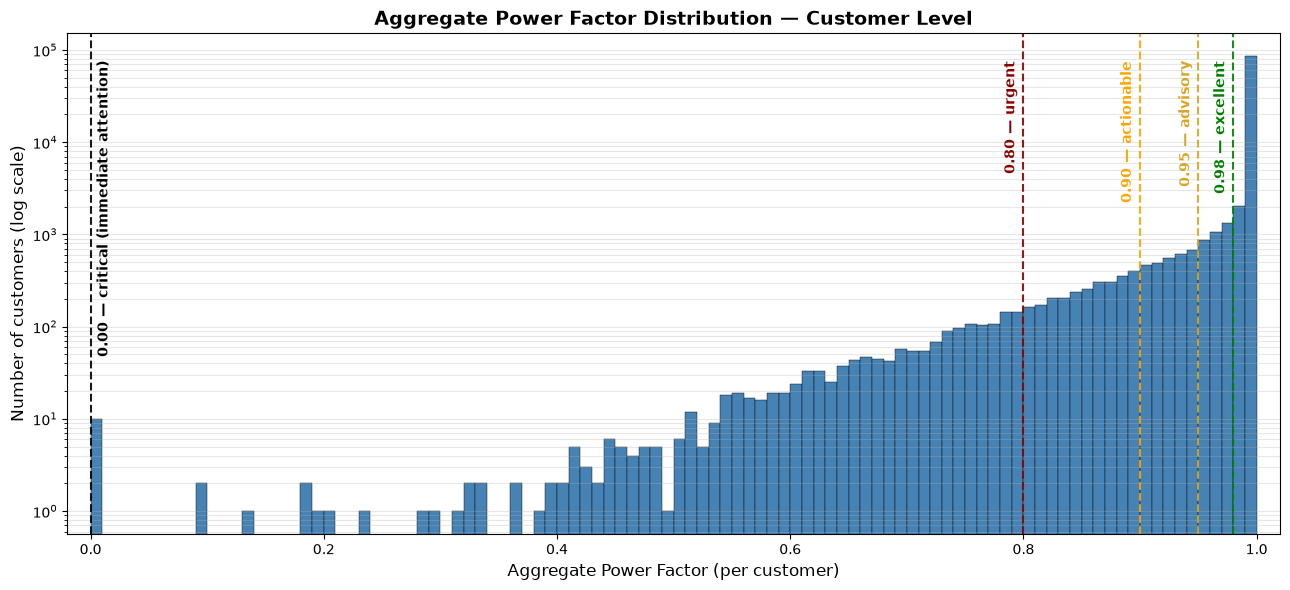

In [8]:
# 1. Materialize customer_pf once — it is currently lazy
customer_pf_df = customer_pf.collect()

# 2. Extract AGG_PF as a NumPy array, dropping nulls
pf_all = (
    customer_pf_df
    .select("AGG_PF")
    .to_series()
    .drop_nulls()
    .to_numpy()
)

# 3. Split into physically distinct populations
pf_inductive = pf_all[(pf_all >= 0) & (pf_all <= 1)]   # normal / inductive load
pf_capacitive = pf_all[pf_all < 0]                     # leading PF

# 4. Count net exporters — this must also be evaluated eagerly
n_prosumers = (
    customer_pf_df
    .select((pl.col("SUM_P") < 0).sum().alias("n"))
    .item()
)

print(f"Customers with valid inductive PF: {len(pf_inductive):,}")
print(f"Customers with capacitive PF:      {len(pf_capacitive):,}")
print(f"Customers that are net exporters: {n_prosumers:,}")

# 5. Build the histogram
bins = np.linspace(0, 1, 101)
counts, edges = np.histogram(pf_inductive, bins=bins)

# 6. Plot setup (using a single, neutral color for bars to prevent threshold mismatch)
fig, ax = plt.subplots(figsize=(13, 6))
ax.bar(
    edges[:-1],
    counts,
    width=np.diff(edges),
    color="steelblue", 
    edgecolor="black",
    linewidth=0.3,
    align="edge",
)

ax.set_yscale("log")

# 7. Define warning thresholds and overlay lines
thresholds = [
    (0.00, "0.00 — critical (immediate attention)", "black"),
    (0.80, "0.80 — urgent",     "darkred"),
    (0.90, "0.90 — actionable", "orange"),
    (0.95, "0.95 — advisory",   "goldenrod"),
    (0.98, "0.98 — excellent",  "green"),
]

for thresh, label, color in thresholds:
    ax.axvline(thresh, color=color, linestyle="--", linewidth=1.5, alpha=0.9)
    
    # Adjust alignment for the 0.0 line to ensure the text remains visible
    ha = "left" if thresh == 0.0 else "right"
    offset = 0.005 if thresh == 0.0 else -0.005
    
    ax.text(
        thresh + offset,
        ax.get_ylim()[1] * 0.5,
        label,
        rotation=90,
        ha=ha,
        va="top",
        fontsize=10,
        fontweight="bold",
        color=color,
    )

# 8. Formatting
ax.set_xlabel("Aggregate Power Factor (per customer)", fontsize=12)
ax.set_ylabel("Number of customers (log scale)", fontsize=12)
ax.set_title("Aggregate Power Factor Distribution — Customer Level", fontsize=14, fontweight="bold")
ax.set_xlim(-0.02, 1.02) # Slightly expanded to fit the 0.0 label
ax.grid(axis="y", alpha=0.3, which="both")

plt.tight_layout()
plt.show()

## Negative consumption

Negative consumption value at any hour mean that during that time period the customer was selling electricity to the DSO rather than consuming it.

In [9]:
neg_active_cust = (
    A
    .filter(
        pl.any_horizontal([
            pl.col(c) < 0
            for c in active_cols
        ])
    )
    .collect()
    .to_pandas()
)
print(f"Rows with at least one negative active value: {len(neg_active_cust):,}")

Rows with at least one negative active value: 775


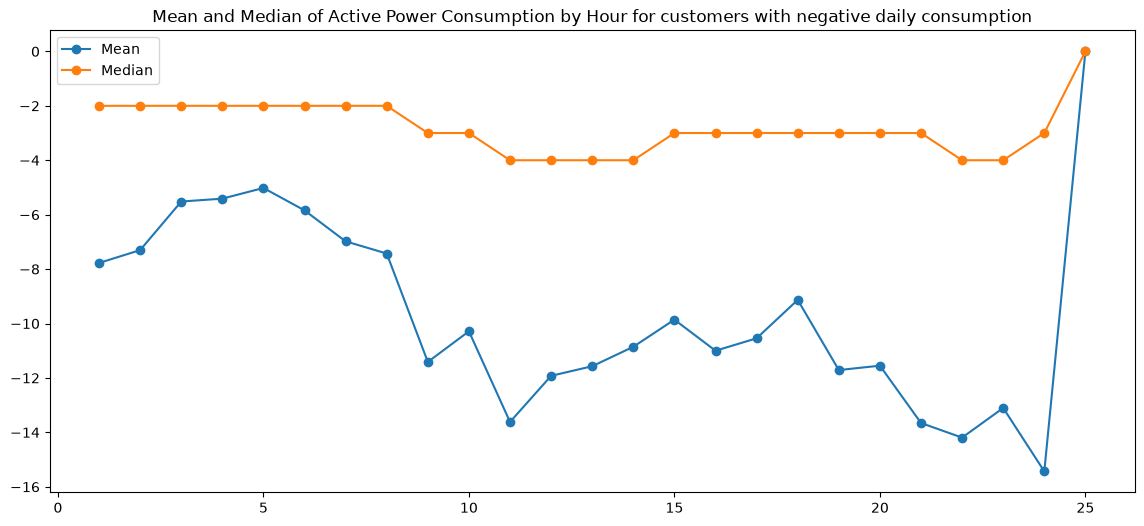

In [10]:
negative_daily_consumption = A.filter(pl.col("DAILY_ACTIVE_CONSUMPTION") < 0).collect().to_pandas()
negative_daily_consumption.shape

neg_active_stats = negative_daily_consumption[active_cols].describe()
plt.figure(figsize=(14, 6))
plt.plot(time_position, neg_active_stats.loc["mean"], marker='o', label='Mean')
plt.plot(time_position, neg_active_stats.loc["50%"], marker='o', label='Median')
plt.legend()
plt.title("Mean and Median of Active Power Consumption by Hour for customers with negative daily consumption")
plt.show()

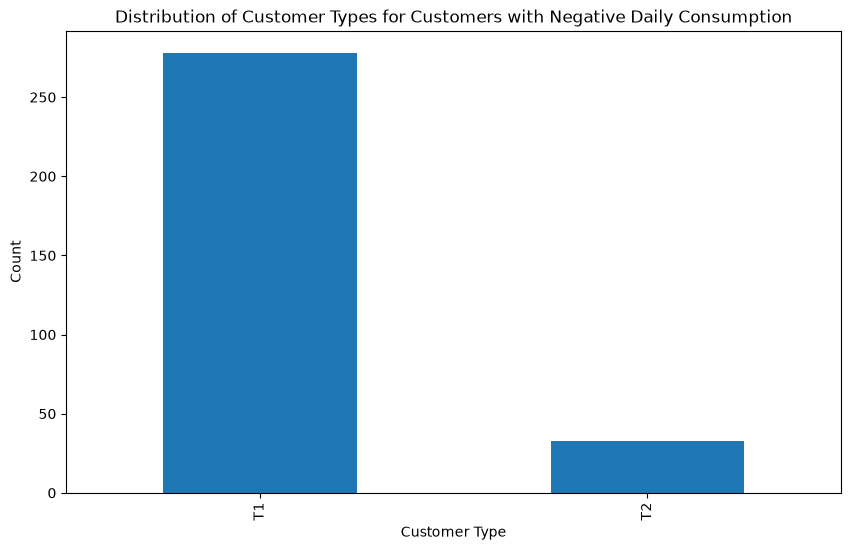

In [11]:
negative_daily_consumption["CUSTOMER_TYPE"].value_counts().plot(kind='bar', figsize=(10, 6))
plt.title("Distribution of Customer Types for Customers with Negative Daily Consumption")
plt.xlabel("Customer Type")
plt.ylabel("Count")
plt.show()

## Exploring the categorical variables

In [12]:
categorical_cols = [
    "CUSTOMER_TYPE",
    "ELECTRICITY_PRODUCT",
    "MARKET",
]

A = A.with_columns([
        pl.col(c).replace("", None)
        for c in categorical_cols
    ])

categorical_overview = (
    A.select([
        pl.col(c).n_unique().alias(c)
        for c in categorical_cols
    ])
    .collect()
)

categorical_overview

CUSTOMER_TYPE,ELECTRICITY_PRODUCT,MARKET
u32,u32,u32
2,86,2


In [13]:
for col in categorical_cols:
    print(f"\n--- {col} ---")
    print(
        A.select(col)
        .unique()
        .sort(col)
        .head(30)
        .collect()
    )


--- CUSTOMER_TYPE ---
shape: (2, 1)
┌───────────────┐
│ CUSTOMER_TYPE │
│ ---           │
│ cat           │
╞═══════════════╡
│ T1            │
│ T2            │
└───────────────┘

--- ELECTRICITY_PRODUCT ---
shape: (30, 1)
┌─────────────────────┐
│ ELECTRICITY_PRODUCT │
│ ---                 │
│ cat                 │
╞═════════════════════╡
│ P1                  │
│ P106                │
│ P11                 │
│ P110                │
│ P111                │
│ …                   │
│ P28                 │
│ P29                 │
│ P3                  │
│ P30                 │
│ P31                 │
└─────────────────────┘

--- MARKET ---
shape: (2, 1)
┌────────┐
│ MARKET │
│ ---    │
│ cat    │
╞════════╡
│ M1     │
│ M2     │
└────────┘


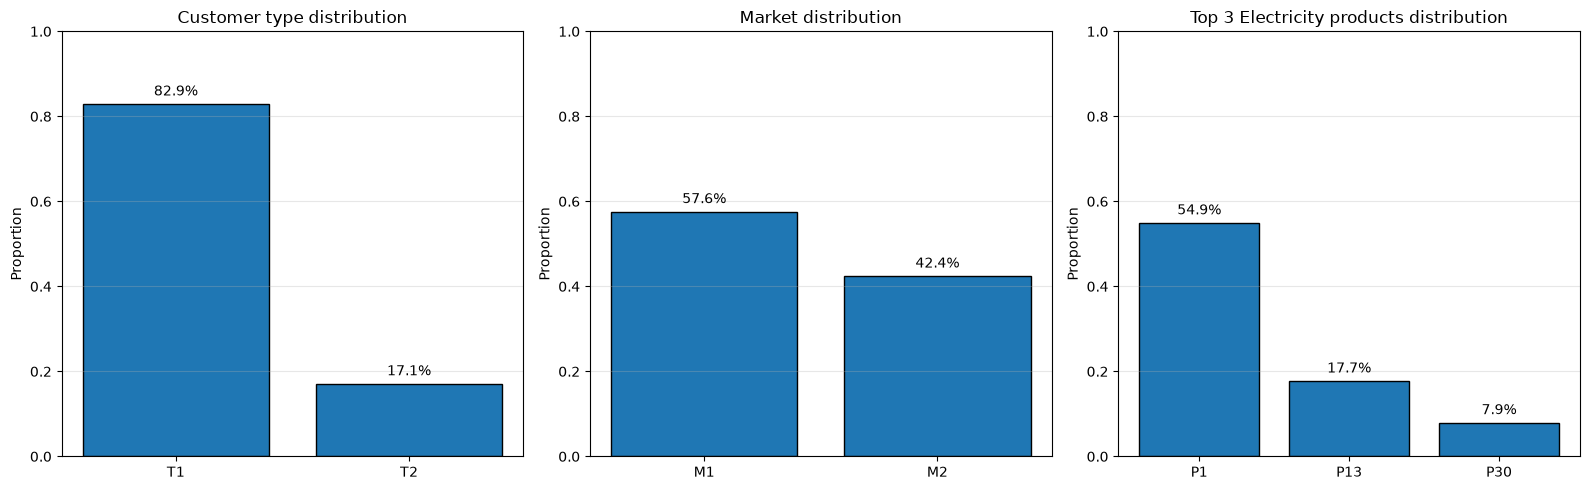

In [14]:
ct = (
    A.select(pl.col("CUSTOMER_TYPE").value_counts(normalize=True))
     .unnest("CUSTOMER_TYPE")
     .collect()
)

mk = (
    A.select(pl.col("MARKET").value_counts(normalize=True))
     .unnest("MARKET")
     .collect()
)

ep = (
    A.select(pl.col("ELECTRICITY_PRODUCT").value_counts(normalize=True))
     .unnest("ELECTRICITY_PRODUCT")
     .sort("proportion", descending=True)
     .collect()
)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].bar(
    ct["CUSTOMER_TYPE"].to_list(),
    ct["proportion"].to_list(),
    edgecolor="black",
)
axes[0].set_title("Customer type distribution")
axes[0].set_ylabel("Proportion")
axes[0].set_ylim(0, 1)
axes[0].grid(axis="y", alpha=0.3)

for x, y in zip(ct["CUSTOMER_TYPE"].to_list(), ct["proportion"].to_list()):
    axes[0].text(x, y + 0.02, f"{y:.1%}", ha="center")

axes[1].bar(
    mk["MARKET"].to_list(),
    mk["proportion"].to_list(),
    edgecolor="black",
)
axes[1].set_title("Market distribution")
axes[1].set_ylabel("Proportion")
axes[1].set_ylim(0, 1)
axes[1].grid(axis="y", alpha=0.3)

for x, y in zip(mk["MARKET"].to_list(), mk["proportion"].to_list()):
    axes[1].text(x, y + 0.02, f"{y:.1%}", ha="center")

axes[2].bar(
    ep["ELECTRICITY_PRODUCT"].to_list()[:3],
    ep["proportion"].to_list()[:3],
    edgecolor="black",
)
axes[2].set_title("Top 3 Electricity products distribution")
axes[2].set_ylabel("Proportion")
axes[2].set_ylim(0, 1)
axes[2].grid(axis="y", alpha=0.3)

for x, y in zip(ep["ELECTRICITY_PRODUCT"].to_list()[:3], ep["proportion"].to_list()[:3]):
    axes[2].text(x, y + 0.02, f"{y:.1%}", ha="center")

plt.tight_layout()
plt.show()

## Supply registration period column

In [15]:
A.select([
    pl.col("SUPPLY_REGISTRATION_PERIOD").is_null().sum().alias("nulls"),
    (pl.col("SUPPLY_REGISTRATION_PERIOD") == "").sum().alias("empties"),
    pl.col("SUPPLY_REGISTRATION_PERIOD").n_unique().alias("distinct"),
]).collect()

nulls,empties,distinct
u32,u32,u32
338139,0,171


In [16]:
A = A.with_columns(
    pl.col("SUPPLY_REGISTRATION_PERIOD").replace("", None)
)

In [17]:
A.select("SUPPLY_REGISTRATION_PERIOD").unique().head().collect()

SUPPLY_REGISTRATION_PERIOD
str
"""Q12001"""
"""Q22011"""
"""Q11990"""
"""Q11965"""
"""Q31985"""


In [18]:
A.select(
    pl.col("SUPPLY_REGISTRATION_PERIOD").str.len_chars().alias("len")
).unique().collect()

len
u32
null
6


In [19]:
A = A.with_columns([
  pl.col("SUPPLY_REGISTRATION_PERIOD")
    .str.slice(1, 1)
    .cast(pl.Int8, strict=False)
    .alias("REG_QUARTER"),

  pl.col("SUPPLY_REGISTRATION_PERIOD")
    .str.slice(2, 5)
    .cast(pl.Int16, strict=False)
    .alias("REG_YEAR"),
])

A.select([
  pl.col("REG_QUARTER").is_null().sum().alias("q_nulls"),
  pl.col("REG_YEAR").is_null().sum().alias("y_nulls"),
]).collect()

q_nulls,y_nulls
u32,u32
338139,338139


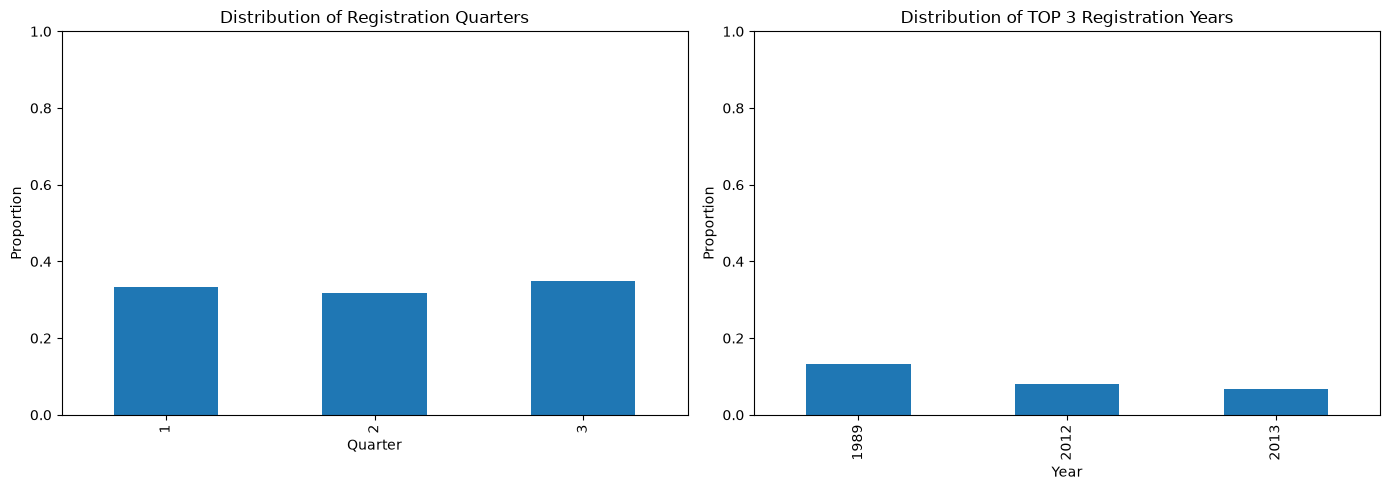

In [20]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

(
    A.filter(pl.col("REG_QUARTER").is_not_null())
    .select(pl.col("REG_QUARTER").value_counts(normalize=True))
    .unnest("REG_QUARTER")
    .sort("REG_QUARTER")
    .collect()
).to_pandas().plot(
    kind="bar",
    x="REG_QUARTER",
    y="proportion",
    legend=False,
    title="Distribution of Registration Quarters",
    xlabel="Quarter",
    ylabel="Proportion",
    ylim=(0, 1),
    ax=ax1, 
)

(
    A.filter(pl.col("REG_YEAR").is_not_null())
    .select(pl.col("REG_YEAR").value_counts(normalize=True))
    .unnest("REG_YEAR")
    .sort("proportion", descending=True)
    .head(3)
    .collect()
).to_pandas().plot(
    kind="bar",
    x="REG_YEAR",
    y="proportion",
    legend=False,
    title="Distribution of TOP 3 Registration Years",
    xlabel="Year",
    ylabel="Proportion",
    ylim=(0, 1),
    ax=ax2,
)

plt.tight_layout()
plt.show()


In [21]:
(
    A.filter(pl.col("REG_YEAR").is_not_null())
    .select(pl.col("REG_YEAR").unique().sort())
    .collect()
)

REG_YEAR
i16
1904
1952
1953
1957
1958
…
2011
2012
2013


## Customer type load shapes

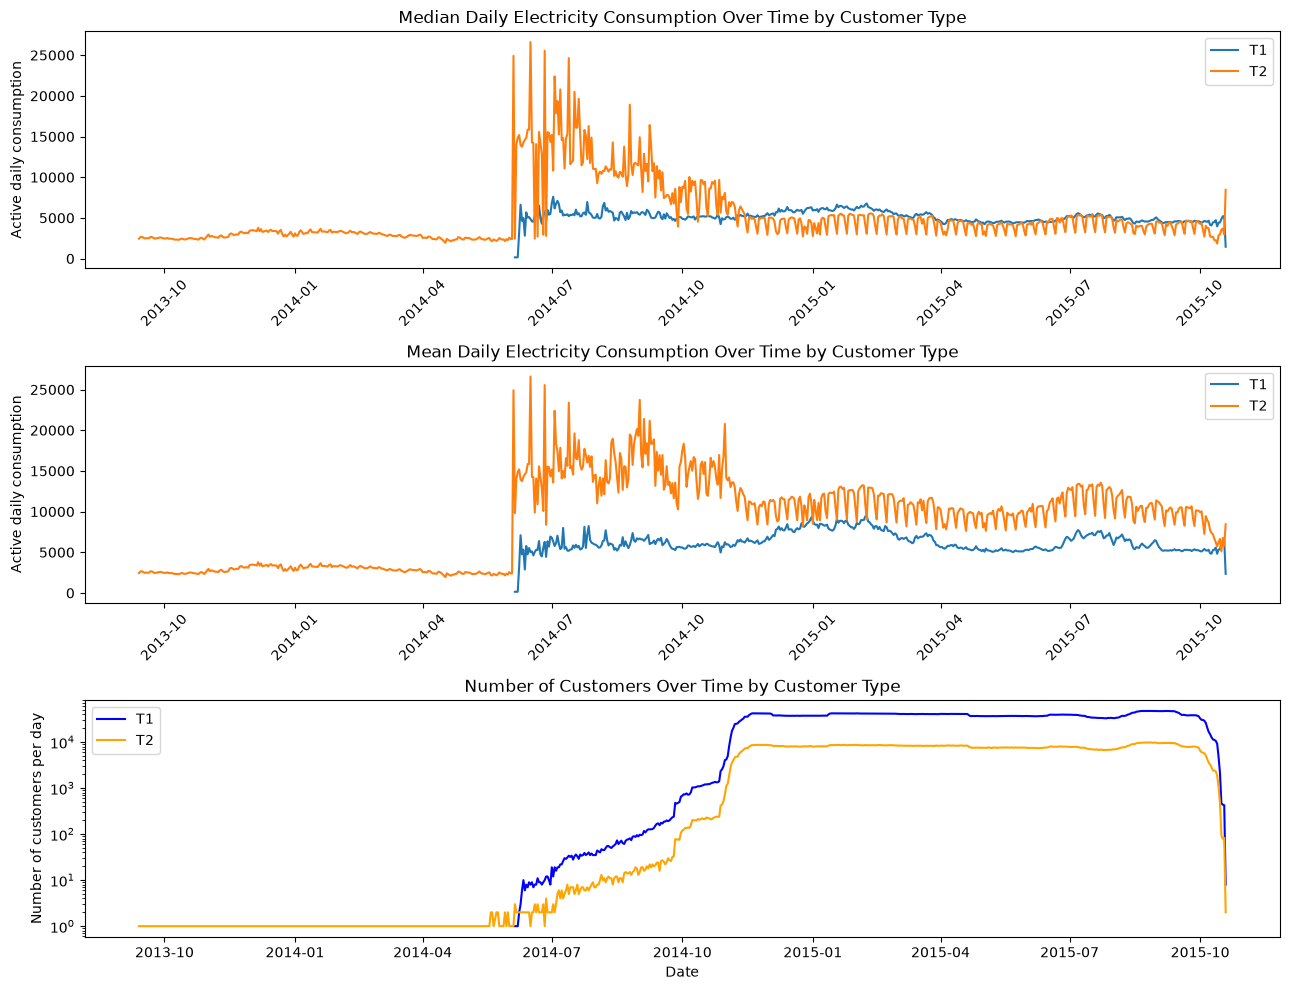

In [22]:
Ctype_load = (
    A
    .group_by("DATE", "CUSTOMER_TYPE")
    .agg([
        pl.col("DAILY_ACTIVE_CONSUMPTION").sum().alias("total_consumption"),
        pl.col("DAILY_ACTIVE_CONSUMPTION").mean().alias("mean_consumption"),
        pl.col("DAILY_ACTIVE_CONSUMPTION").median().alias("median_consumption"),
        pl.col("CUSTOMER_ID").n_unique().alias("customers"),
        pl.len().alias("observations"),
    ])
    .sort("DATE")
    .collect()
)

plt.figure(figsize=(13, 10))
plt.subplot(3,1,1)
Ctype_load_t1 = Ctype_load.filter(pl.col("CUSTOMER_TYPE") == "T1")
Ctype_load_t2 = Ctype_load.filter(pl.col("CUSTOMER_TYPE") == "T2")
plt.plot(
    Ctype_load_t1["DATE"].to_numpy(),
    Ctype_load_t1["median_consumption"].to_numpy(),
)
plt.plot(
    Ctype_load_t2["DATE"].to_numpy(),
    Ctype_load_t2["median_consumption"].to_numpy(),
)
plt.ylabel("Active daily consumption")
plt.title("Median Daily Electricity Consumption Over Time by Customer Type")
plt.xticks(rotation=45)
plt.legend(["T1", "T2"])

plt.subplot(3,1,2)
Ctype_load_t1 = Ctype_load.filter(pl.col("CUSTOMER_TYPE") == "T1")
Ctype_load_t2 = Ctype_load.filter(pl.col("CUSTOMER_TYPE") == "T2")
plt.plot(
    Ctype_load_t1["DATE"].to_numpy(),
    Ctype_load_t1["mean_consumption"].to_numpy(),
)
plt.plot(
    Ctype_load_t2["DATE"].to_numpy(),
    Ctype_load_t2["mean_consumption"].to_numpy(),
)
plt.ylabel("Active daily consumption")
plt.title("Mean Daily Electricity Consumption Over Time by Customer Type")
plt.xticks(rotation=45)
plt.legend(["T1", "T2"])


plt.subplot(3,1,3)
plt.plot(
    Ctype_load_t1["DATE"].to_numpy(),
    Ctype_load_t1["customers"].to_numpy(),
    c='blue'
)
plt.plot(
    Ctype_load_t2["DATE"].to_numpy(),
    Ctype_load_t2["customers"].to_numpy(),
    c='orange'
)
plt.ylabel("Number of customers per day")
plt.title("Number of Customers Over Time by Customer Type")
plt.legend(["T1", "T2"])

plt.xlabel("Date")
plt.yscale('log')
plt.tight_layout()
plt.show()

In [23]:
(
    A
    .filter(
    (pl.col("DATE") >= pl.datetime(2013, 9, 1)) & (pl.col("DATE") <= pl.datetime(2014, 4, 30)))
    .select(pl.col("CUSTOMER_ID"))
    .unique()
    .collect()
)

CUSTOMER_ID
i64
10470


## Customers and Load Consumption across Municipalities

In [24]:
muni_load = (
    A
    .group_by("MUNICIPALITY")
    .agg([
        pl.col("CUSTOMER_ID").n_unique().alias("N_CUSTOMERS"),
        pl.col("DAILY_ACTIVE_CONSUMPTION").sum().alias("TOTAL_ACTIVE"),
        pl.col("DAILY_REACTIVE_CONSUMPTION").sum().alias("TOTAL_REACTIVE"),
        pl.col("DAILY_ACTIVE_CONSUMPTION").mean().alias("MEAN_ACTIVE_PER_DAY"),
        pl.col("CUSTOMER_TYPE").mode().first().alias("MOST_COMMON_CUSTOMER_TYPE"),
    ])
    .with_columns(
        pl.when(pl.col("N_CUSTOMERS") == 1)
          .then(pl.lit("1"))
          .when(pl.col("N_CUSTOMERS") <= 10)
          .then(pl.lit("2-10"))
          .when(pl.col("N_CUSTOMERS") <= 1000)
          .then(pl.lit("11-1000"))
          .when(pl.col("N_CUSTOMERS") <= 5000)
          .then(pl.lit("1001-5000"))
          .otherwise(pl.lit(">5000"))
          .alias("N_CUSTOMER_BUCKET")
    )
    .with_columns(
        pl.col("N_CUSTOMER_BUCKET").cast(
            pl.Enum(["1", "2-10", "11-1000", "1001-5000", ">5000"])
        )
    )
    .sort("TOTAL_ACTIVE", descending=True)
)

muni_load.head().collect()

MUNICIPALITY,N_CUSTOMERS,TOTAL_ACTIVE,TOTAL_REACTIVE,MEAN_ACTIVE_PER_DAY,MOST_COMMON_CUSTOMER_TYPE,N_CUSTOMER_BUCKET
str,u32,i64,i64,f64,cat,enum
"""MADRID""",7478,8358063180,2079379868,7296.056493,"""T1""",""">5000"""
"""SANT BOI DE LLOBREGAT""",4156,5030020798,0,7480.252213,"""T1""","""1001-5000"""
"""RUBI""",3540,4063265116,0,7328.236155,"""T1""","""1001-5000"""
"""MAIRENA DEL ALCOR""",2773,3900120293,0,8540.30966,"""T1""","""1001-5000"""
"""L'HOSPITALET DE LLOBREGAT""",4047,3537392869,0,5599.204879,"""T1""","""1001-5000"""


C:\Users\reema\AppData\Local\Temp\ipykernel_17944\2395950299.py:13: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:steelblue'` for the same effect.

  sns.barplot(


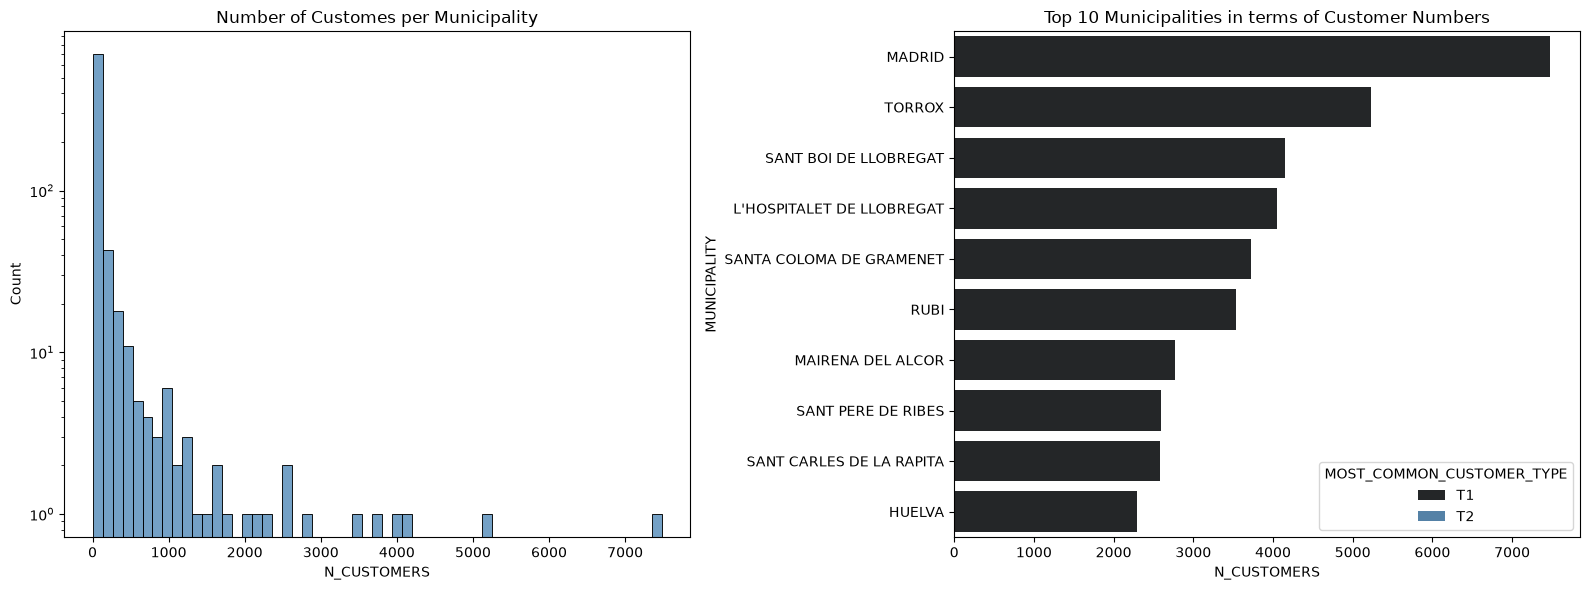

In [25]:
fig, (ax1, ax2) = plt.subplots(1,2,figsize=(16, 6))
muni_load_df = muni_load.collect().to_pandas()
sns.histplot(
    data=muni_load_df,
    x="N_CUSTOMERS",
    ax=ax1,
    color="steelblue",
)
ax1.set_yscale('log')
ax1.set_title('Number of Customes per Municipality')


sns.barplot(
    data=muni_load_df.sort_values(by="N_CUSTOMERS", ascending=False).head(10),
    y="MUNICIPALITY",
    x="N_CUSTOMERS",
    hue="MOST_COMMON_CUSTOMER_TYPE",
    ax=ax2,
    color="steelblue",
)
ax2.set_title('Top 10 Municipalities in terms of Customer Numbers')

plt.tight_layout()
plt.show()

C:\Users\reema\AppData\Local\Temp\ipykernel_17944\3878817086.py:16: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:steelblue'` for the same effect.

  sns.barplot(


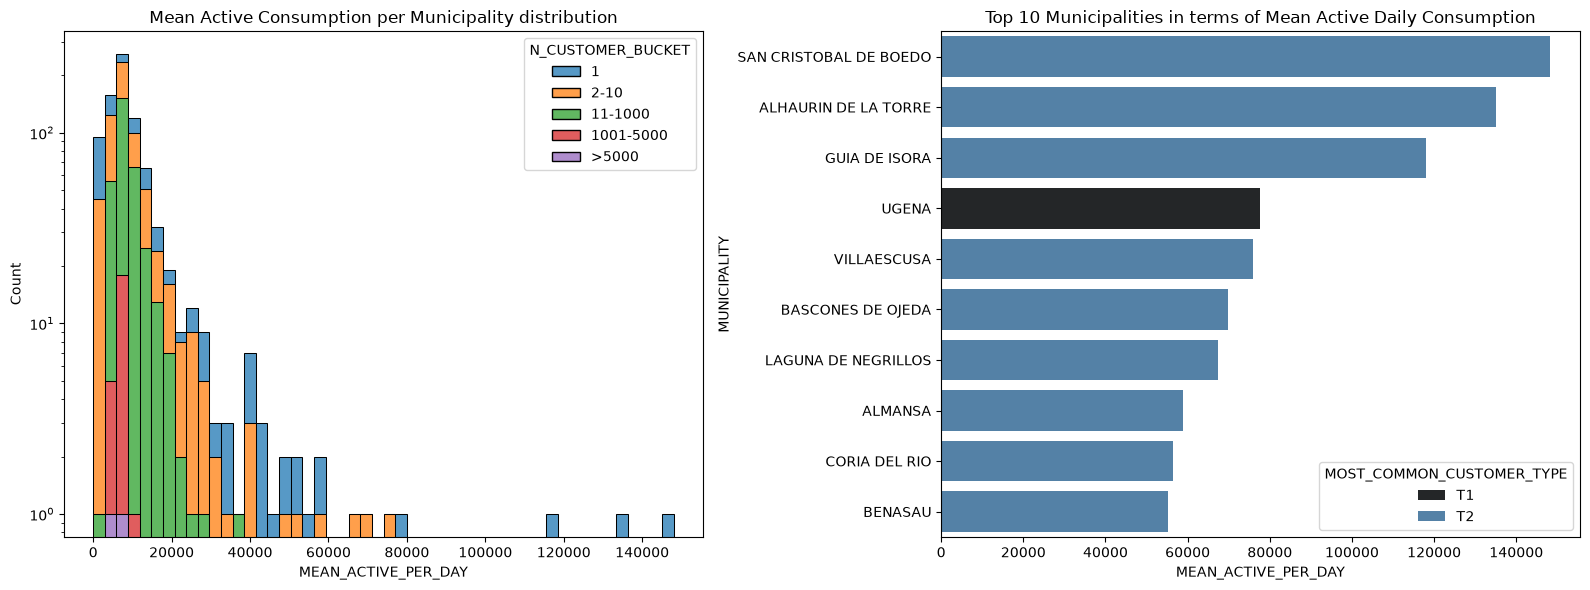

In [26]:
fig, (ax1, ax2) = plt.subplots(1,2,figsize=(16, 6))

sns.histplot(
    data=muni_load_df,
    x="MEAN_ACTIVE_PER_DAY",
    hue="N_CUSTOMER_BUCKET",
    hue_order=["1", "2-10", "11-1000", "1001-5000", ">5000"],
    bins=50,
    ax=ax1,
    multiple="stack",
    # color="steelblue",
)
ax1.set_yscale('log')
ax1.set_title('Mean Active Consumption per Municipality distribution')

sns.barplot(
    data=muni_load_df.sort_values(by="MEAN_ACTIVE_PER_DAY", ascending=False).head(10),
    y="MUNICIPALITY",
    x="MEAN_ACTIVE_PER_DAY",
    hue="MOST_COMMON_CUSTOMER_TYPE",
    ax=ax2,
    color="steelblue",
)
ax2.set_title('Top 10 Municipalities in terms of Mean Active Daily Consumption')

plt.tight_layout()
plt.show()

In [27]:
def plot_top_municipalities(
    muni_load_df,
    munis_df,
    metric="N_CUSTOMERS",
    top_n=10,
    title=None,
    figsize=(14, 7),
    cmap="viridis",
):
    """
    Plot the top-N municipalities (by `metric`) on a map of Spain,
    with markers colored by the metric value.

    Parameters
    ----------
    muni_load_df : pd.DataFrame
        Aggregated per-municipality metrics. Must contain a 'MUNICIPALITY'
        column and the `metric` column. (No coordinate columns required.)
    munis_df : pd.DataFrame
        Geographic reference table with 'DE_MUNICIP_org', 'longitude',
        'latitude'.
    metric : str
        Column in `muni_load_df` used for ranking and coloring.
    """
    # ---- 1. Attach coordinates to the load data -------------------------
    merged = muni_load_df.merge(
        munis_df[["DE_MUNICIP_org", "longitude", "latitude"]],
        left_on="MUNICIPALITY",
        right_on="DE_MUNICIP_org",
        how="left",
    ).dropna(subset=["longitude", "latitude"])

    if merged.empty:
        raise ValueError(
            "No municipalities could be matched to coordinates. "
            "Check that MUNICIPALITY values align with DE_MUNICIP_org."
        )

    top = merged.sort_values(metric, ascending=False).head(top_n).copy()

    # ---- 2. Shared color scale ------------------------------------------
    norm = plt.Normalize(vmin=top[metric].min(), vmax=top[metric].max())
    cmap_obj = plt.get_cmap(cmap)

    fig, (ax_main, ax_can) = plt.subplots(
        1, 2, figsize=figsize,
        gridspec_kw={"width_ratios": [3, 1]},
    )

    # ---- 3. Panel-drawing helper ----------------------------------------
    def draw_panel(ax, lon_min, lon_max, lat_min, lat_max, subtitle):
        # Background: every municipality as a faint dot for context
        bg = munis_df[
            munis_df["longitude"].between(lon_min, lon_max)
            & munis_df["latitude"].between(lat_min, lat_max)
        ]
        ax.scatter(
            bg["longitude"], bg["latitude"],
            s=4, c="lightgrey", alpha=0.6, zorder=1,
        )

        # Foreground: the top-N subset inside this bbox
        fg = top[
            top["longitude"].between(lon_min, lon_max)
            & top["latitude"].between(lat_min, lat_max)
        ]
        if not fg.empty:
            ax.scatter(
                fg["longitude"], fg["latitude"],
                s=140,
                c=fg[metric],
                cmap=cmap_obj,
                norm=norm,
                edgecolor="black",
                linewidth=0.7,
                zorder=3,
            )
            for _, row in fg.iterrows():
                ax.annotate(
                    str(row["MUNICIPALITY"]).title(),
                    (row["longitude"], row["latitude"]),
                    xytext=(7, 5), textcoords="offset points",
                    fontsize=8, fontweight="bold", color="black",
                    bbox=dict(boxstyle="round,pad=0.2",
                              fc="white", ec="gray", alpha=0.3),
                    zorder=4,
                )

        ax.set_xlim(lon_min, lon_max)
        ax.set_ylim(lat_min, lat_max)
        ax.set_aspect("equal")
        ax.set_title(subtitle, fontsize=11)
        ax.grid(alpha=0.25, linestyle="--")
        ax.set_xlabel("Longitude")
        ax.set_ylabel("Latitude")

    # ---- 4. Mainland + Balearics | Canary Islands -----------------------
    draw_panel(ax_main, -10, 5, 35, 44, "Mainland + Balearics")
    draw_panel(ax_can, -19, -13, 27, 30, "Canary Islands")

    # ---- 5. Colorbar shared across both panels --------------------------
    sm = plt.cm.ScalarMappable(cmap=cmap_obj, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(
        sm,
        ax=[ax_main, ax_can],
        fraction=0.025,
        pad=0.02,
    )
    cbar.set_label(metric, fontsize=10)

    fig.suptitle(
        title or f"Top {top_n} municipalities by {metric}",
        fontsize=13, fontweight="bold",
    )
    # plt.tight_layout()
    plt.show()

In [28]:
munis = pl.read_csv(r'../BD_MUNICIPIOS-ENTIDADES/geo_encoded_munis.csv')
munis.head()

,DE_MUNICIP_org,INE5,latitude,longitude,altitude,CODNUT2,ccaa,Province_code,Province,Municipality,Year,to_coast_km,to_mad_km,to_prov_cap_km,ruggedness,area,pp,t_average,spei,grow_period_pp,frost_days,dry_hot_climate,dry_cold_climate,oceanic,mediterranean,mediterranean_fresh_summer,humid_hot,continental_fresh_summer,continental_boreal,climate_zone_cluster
i64,str,i64,f64,f64,f64,str,str,f64,str,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0,"""A CORUÃ‘A""",15030,43.371495,-8.395826,8.0,"""ES11""","""Galicia""",15.0,"""a Coruña""","""A Coruña""","""2010s""",0.186361,510.59659,0.177249,54.355599,37.987598,1107.880019,14.075,-0.258633,435.760009,15.463,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,3.0
1,"""ABIA DE LAS TORRES""",34003,42.42022,-4.421902,836.0,"""ES41""","""Castilla y León""",34.0,"""Palencia""","""Abia de las Torres""","""2010s""",106.84114,231.52803,46.431713,18.765692,27.111401,458.12001,13.200834,-0.435652,228.450005,48.376999,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,"""ABRERA""",8001,41.516398,1.901569,106.0,"""ES51""","""Cataluña""",8.0,"""Barcelona""","""Abrera""","""2010s""",28.03347,486.4238,27.359745,49.19894,20.1292,562.55001,15.401667,-0.259144,334.750006,23.533499,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
3,"""ACEBEDO""",24001,43.040732,-5.115871,1148.0,"""ES41""","""Castilla y León""",24.0,"""León""","""Acebedo""","""2010s""",46.55978,315.39801,61.069183,193.161104,50.297699,734.985012,11.203333,-0.316846,340.055006,68.914498,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,"""ACEUCHAL""",6002,38.647755,-6.487251,303.0,"""ES43""","""Extremadura""",6.0,"""Badajoz""","""Aceuchal""","""2010s""",152.40154,310.11331,49.322891,27.376035,63.1124,424.215007,17.422917,-0.370864,172.125002,20.676999,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [29]:
duplicate_munis = munis.filter(pl.col("DE_MUNICIP_org").is_duplicated()==True).to_pandas()
duplicate_munis[["DE_MUNICIP_org", "Province", "climate_zone_cluster"]]

,DE_MUNICIP_org,Province,climate_zone_cluster
0,CABANES,Castellón,1.0
1,CABANES,Girona,1.0
2,CIEZA,Murcia,1.0
3,CIEZA,Cantabria,3.0
4,LA CONCHA,Zamora,0.0
5,LA CONCHA,Cantabria,3.0
6,MIERES,Girona,1.0
7,MIERES,Asturias,3.0
8,MIERES DEL CAMIN,Girona,1.0
9,MIERES DEL CAMIN,Asturias,3.0


(808, 31)
Municipalities we're not sure about their coordinates: ['CABANES' 'CIEZA' 'LA CONCHA' 'MIERES' 'MIERES DEL CAMIN' 'SADA'
 'TORRENT' 'VILLAESCUSA' 'VILLAYUSO']


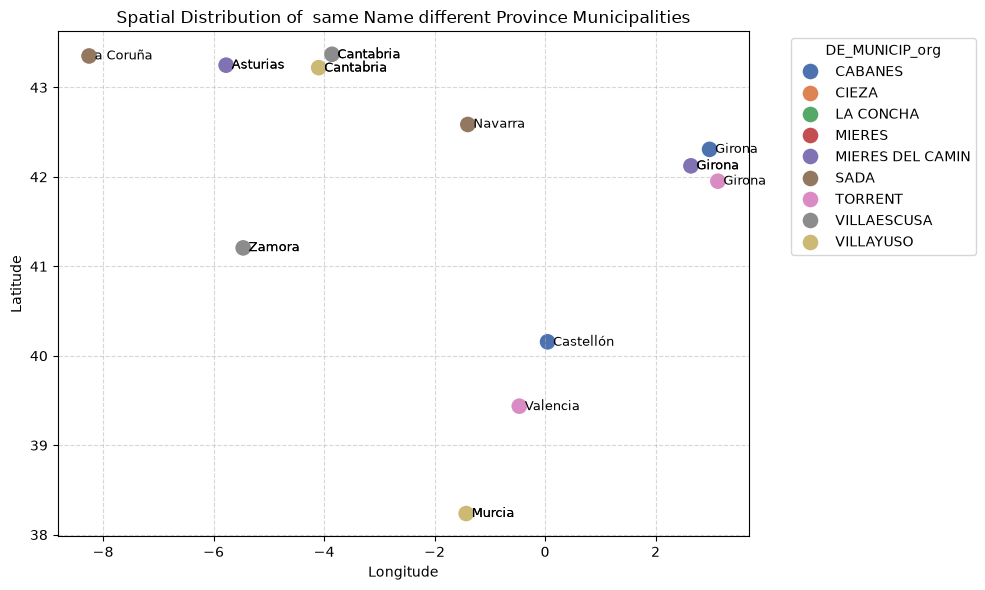

In [30]:
inaccurate_munis = duplicate_munis.DE_MUNICIP_org.unique()
munis = munis.unique(subset="DE_MUNICIP_org")
print(munis.shape)
print(f"Municipalities we're not sure about their coordinates: {inaccurate_munis}")
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=duplicate_munis,
    x="longitude",
    y="latitude",
    hue="DE_MUNICIP_org",
    s=150,           
    palette="deep"   
)

for _, row in duplicate_munis.iterrows():
    label = row["Province"]
    plt.text(
        x=row["longitude"] + 0.1,
        y=row["latitude"], 
        s=label,
        fontsize=9,
        verticalalignment='center'
    )

plt.title("Spatial Distribution of  same Name different Province Municipalities")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.legend(title="DE_MUNICIP_org", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

In [31]:
print(f"Number of rows in A with MUNICIPALITY in the list of inaccurate municipalities: {(
    A.filter(pl.col("MUNICIPALITY").is_in(inaccurate_munis))
    .select(pl.len())
    .collect()
).item()} rows")

print(f"Number of unique customers in A with MUNICIPALITY in the list of inaccurate municipalities: {(
    A.filter(pl.col("MUNICIPALITY").is_in(inaccurate_munis))
    .select(pl.col("CUSTOMER_ID").n_unique())
    .collect()
).item()} Customers")

Number of rows in A with MUNICIPALITY in the list of inaccurate municipalities: 15821 rows
Number of unique customers in A with MUNICIPALITY in the list of inaccurate municipalities: 102 Customers


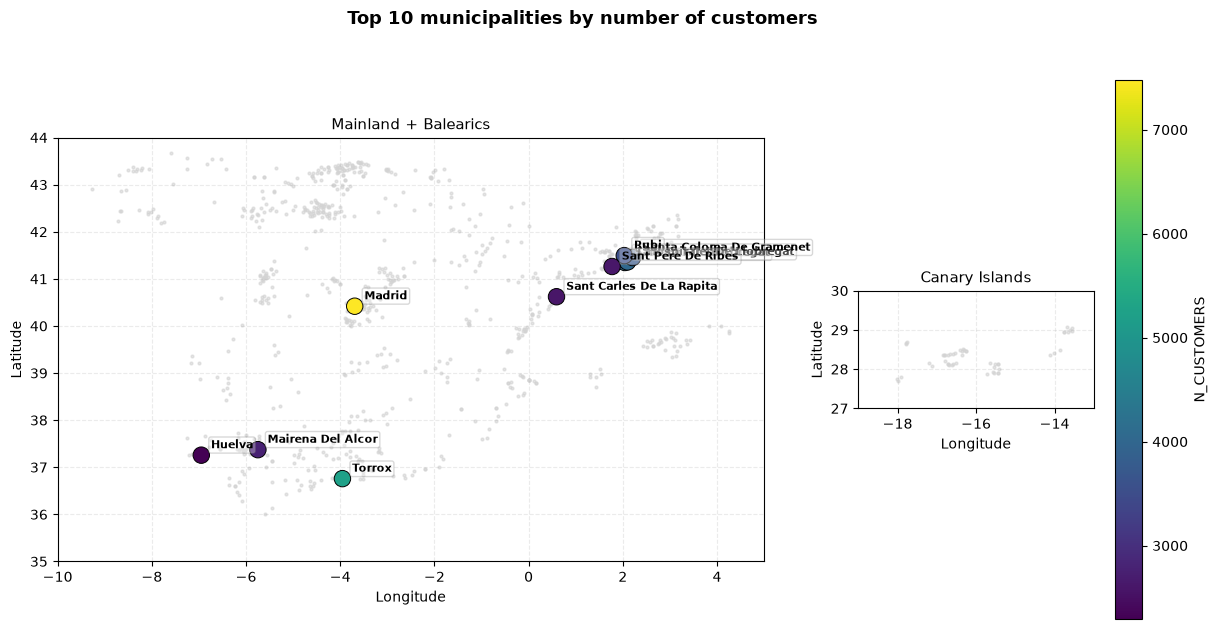

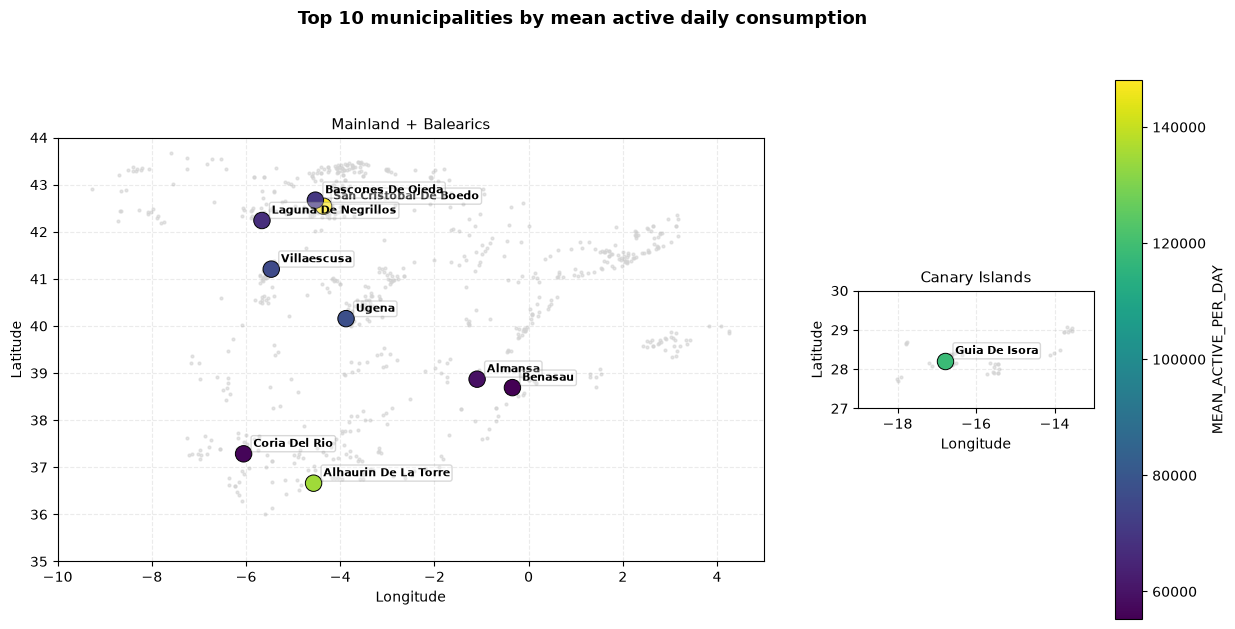

In [32]:
munis_df = munis.to_pandas()
plot_top_municipalities(
    muni_load_df,
    munis_df,
    metric="N_CUSTOMERS",
    title="Top 10 municipalities by number of customers",
)

plot_top_municipalities(
    muni_load_df,
    munis_df,
    metric="MEAN_ACTIVE_PER_DAY",
    title="Top 10 municipalities by mean active daily consumption",
)

In [56]:
munis_to_remove = ['CIEZA', 'LA CONCHA', 'MIERES', 'MIERES DEL CAMIN', 'VILLAESCUSA', 'VILLAYUSO']
filtered_munis = munis.filter(~pl.col("DE_MUNICIP_org").is_in(munis_to_remove))


MIN_DAYS_PER_CUST_MONTH = 20   # customer-month must be >= 20 observed days
MIN_CUSTOMERS_PER_CELL = 30    # drop zone-months with fewer customers

def zone_month_table(A: pl.LazyFrame, lookup: pl.DataFrame, by_type: bool = True) -> pl.DataFrame:
    """by_type=True keeps T1/T2 separate (never mix household-scale and industrial-scale customers)."""
    tcols = ["CUSTOMER_TYPE"] if by_type else []
    # 1) customer x month level first, so each customer counts once per month
    cust_month = (
        A.join(lookup.lazy(), left_on="MUNICIPALITY", right_on="DE_MUNICIP_org", how="inner")
        #  .filter(pl.col("DAILY_ACTIVE_CONSUMPTION") >= 0)      
         .with_columns(pl.col("DATE").dt.truncate("1mo").alias("MONTH"))
         .group_by("CUSTOMER_ID", *tcols, "climate_zone_cluster", "MONTH")
         .agg(pl.col("DAILY_ACTIVE_CONSUMPTION").mean().alias("CUST_MEAN_DAILY"),
              pl.len().alias("N_DAYS"))
         .filter(pl.col("N_DAYS") >= MIN_DAYS_PER_CUST_MONTH)
    )
    # 2) within-customer index: month level / that customer's own average month
    cust_month = cust_month.with_columns(
        (pl.col("CUST_MEAN_DAILY") / pl.col("CUST_MEAN_DAILY").mean().over("CUSTOMER_ID"))
        .alias("SEASONAL_INDEX"),
        pl.len().over("CUSTOMER_ID").alias("N_MONTHS_CUST"),
    ).filter(pl.col("N_MONTHS_CUST") >= 6)   # index meaningless for 1-2 month customers
    # 3) aggregate across customers with n and spread
    return (
        cust_month.group_by(*tcols, "climate_zone_cluster", "MONTH")
        .agg(pl.len().alias("N_CUSTOMERS"),
             pl.col("CUST_MEAN_DAILY").median().alias("MEDIAN"),
             pl.col("CUST_MEAN_DAILY").quantile(0.25).alias("Q25"),
             pl.col("CUST_MEAN_DAILY").quantile(0.75).alias("Q75"),
             pl.col("SEASONAL_INDEX").median().alias("MEDIAN_INDEX"))
        .filter(pl.col("N_CUSTOMERS") >= MIN_CUSTOMERS_PER_CELL)
        .sort(*tcols, "climate_zone_cluster", "MONTH")
        .collect()
    )


cust_zone = zone_month_table(A, filtered_munis, by_type=True)
cust_zone.head()

CUSTOMER_TYPE,climate_zone_cluster,MONTH,N_CUSTOMERS,MEDIAN,Q25,Q75,MEDIAN_INDEX
cat,f64,date,u32,f64,f64,f64,f64
"""T1""",0.0,2014-09-01,64,5413.568182,3397.347826,8091.586207,0.88894
"""T1""",0.0,2014-10-01,571,5232.230769,3398.416667,7742.322581,0.929107
"""T1""",0.0,2014-11-01,5552,5513.456522,3243.846154,8219.1,1.020922
"""T1""",0.0,2014-12-01,4585,5923.428571,2846.153846,9778.482759,1.090894
"""T1""",0.0,2015-01-01,5044,6010.391705,2940.851852,9779.517241,1.110947


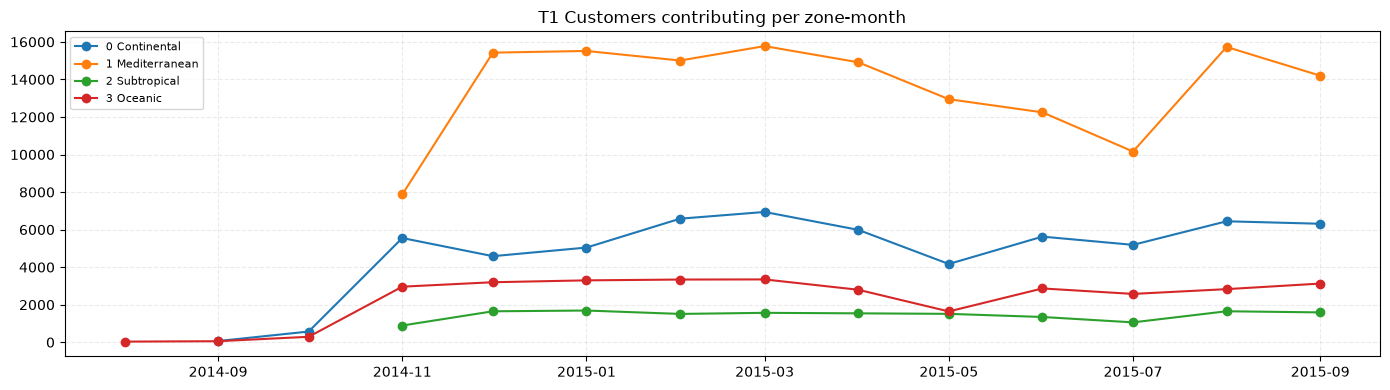

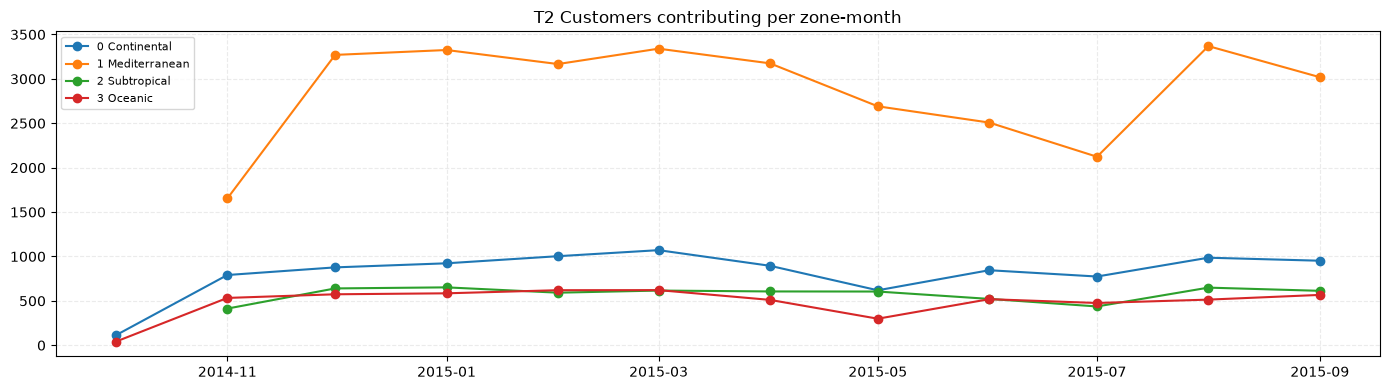

In [57]:
ZONE_NAMES = {
    0: "0 Continental",
    1: "1 Mediterranean",
    2: "2 Subtropical ",
    3: "3 Oceanic",
    }
def plot_zone_customer_number(pdf, customer_type="T1"):
    fig, ax = plt.subplots(figsize=(14, 4), sharex=True)
    pdf = pdf[pdf.CUSTOMER_TYPE == customer_type]
    for z, g in pdf.groupby("climate_zone_cluster"):
        lab = ZONE_NAMES.get(int(z), str(z))
        # ax[0].plot(g.MONTH, g.MEDIAN, marker="o", label=lab)
        # ax[0].fill_between(g.MONTH, g.Q25, g.Q75, alpha=0.12)
        # ax[1].plot(g.MONTH, g.MEDIAN_INDEX, marker="o", label=lab)
        ax.plot(g.MONTH, g.N_CUSTOMERS, marker="o", label=lab)
    # ax[0].set_title(f"Median customer {customer_type} daily active consumption (band = IQR)")
    # ax[1].set_title("Within-customer seasonal index (1.0 = customer's own average month)")
    ax.set_title(f"{customer_type} Customers contributing per zone-month"); 
    ax.legend(fontsize=8)
    ax.grid(alpha=.25, ls="--")
    plt.tight_layout(); plt.show()


pdf = cust_zone.to_pandas()
plot_zone_customer_number(pdf, customer_type="T1")
plot_zone_customer_number(pdf, customer_type="T2")

## Customer Timeseries data Analysis

In [35]:
summary = (
    A
    .group_by("CUSTOMER_ID")
    .agg([
        pl.col("DATE").min().alias("FIRST_DATE"),
        pl.col("DATE").max().alias("LAST_DATE"),
        pl.col("DATE").n_unique().alias("DISTINCT_DATES"),
    ])
    .with_columns(
        ((pl.col("LAST_DATE") - pl.col("FIRST_DATE")).dt.total_days() + 1)
            .alias("SPAN_DAYS")
    )
    .with_columns([
        (pl.col("SPAN_DAYS") - pl.col("DISTINCT_DATES")).alias("MISSING_DAYS"),
        (pl.col("SPAN_DAYS") == pl.col("DISTINCT_DATES")).alias("IS_CONTINUOUS"),
    ])
)
summary = summary.collect().to_pandas()
print(summary.shape[0])
summary.head()

99999


,CUSTOMER_ID,FIRST_DATE,LAST_DATE,DISTINCT_DATES,SPAN_DAYS,MISSING_DAYS,IS_CONTINUOUS
0,86922,2014-11-08,2015-09-13,26,310,284,False
1,85475,2015-01-15,2015-09-28,29,257,228,False
2,97655,2014-11-08,2015-10-07,280,334,54,False
3,48122,2014-12-01,2015-10-09,33,313,280,False
4,19025,2014-11-07,2015-09-22,55,320,265,False


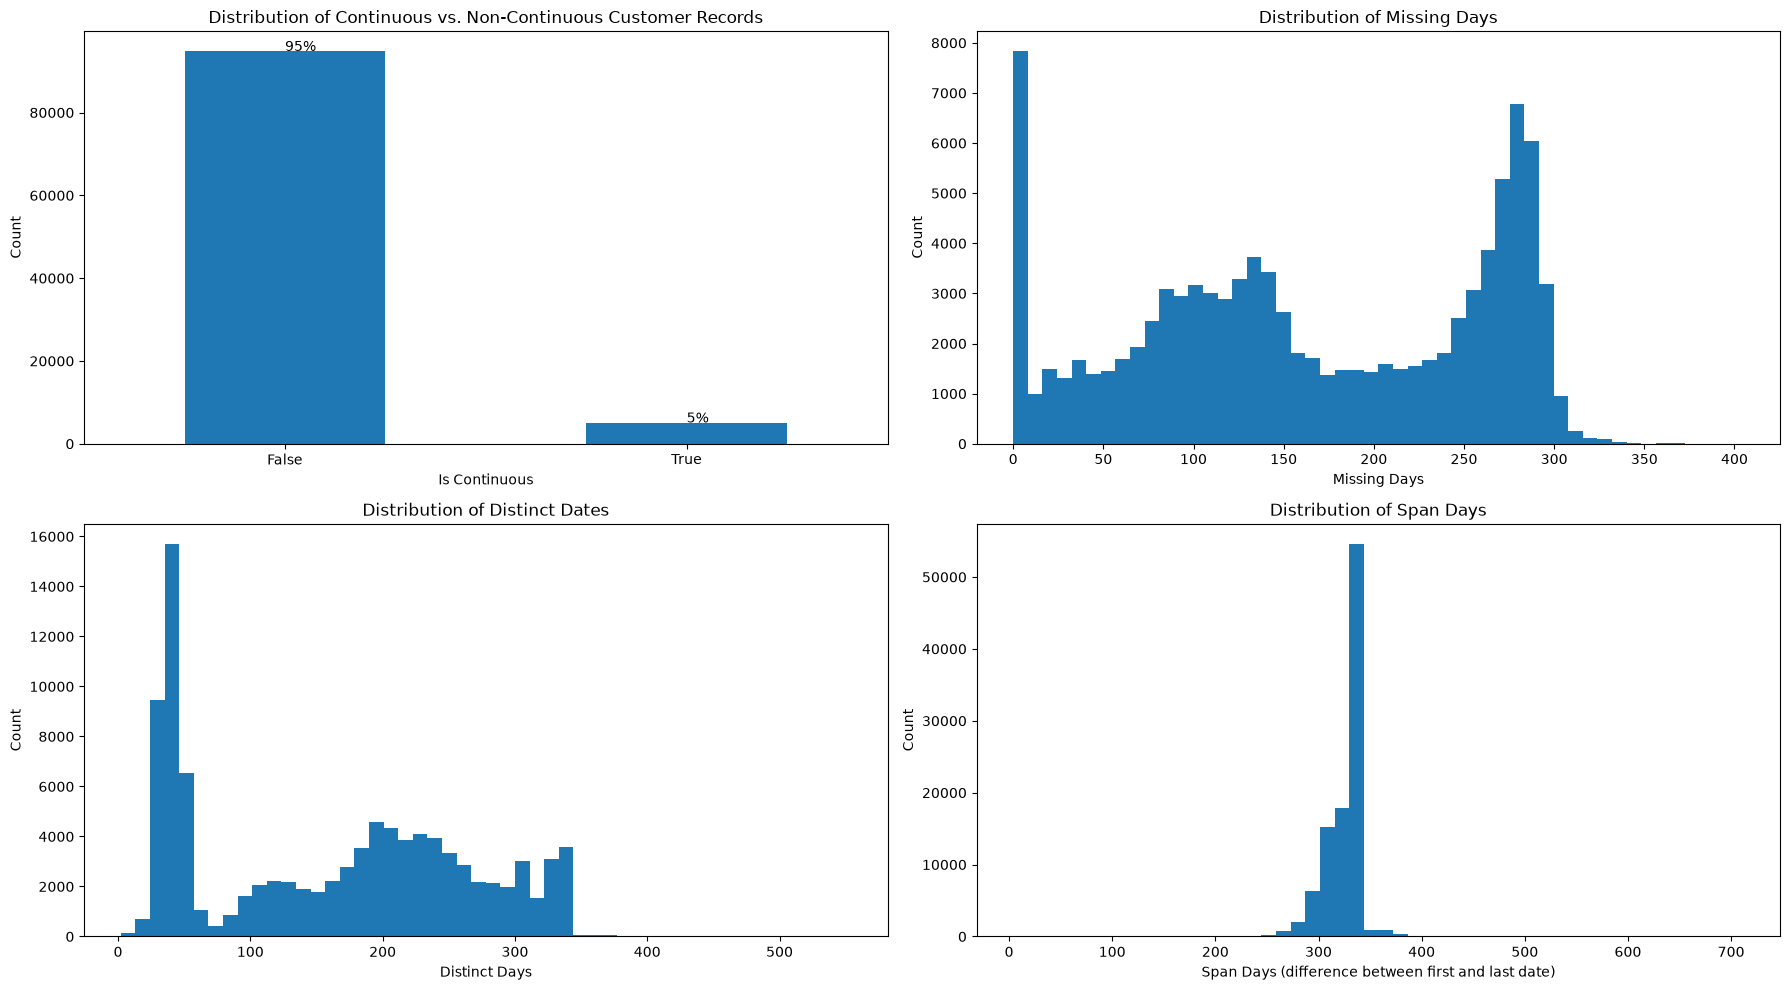

In [36]:
fig, ((axes1, axes2), (axes3, axes4)) = plt.subplots(2, 2, figsize=(18, 10))

is_continuous = summary.IS_CONTINUOUS.value_counts()

is_continuous.plot(kind='bar', ax=axes1)
axes1.set_title("Distribution of Continuous vs. Non-Continuous Customer Records")
axes1.set_xlabel("Is Continuous")
axes1.set_ylabel("Count")
axes1.set_xticklabels(axes1.get_xticklabels(), rotation=0)
false_height = is_continuous[False]
true_height = is_continuous[True]
no_customers = summary.shape[0]
axes1.annotate(f"{is_continuous[False]/no_customers:.0%}", xy=(0, false_height+2))
axes1.annotate(f"{is_continuous[True]/no_customers:.0%}", xy=(1, true_height+2))

summary.MISSING_DAYS.plot(kind='hist', bins=50, ax=axes2)
axes2.set_title("Distribution of Missing Days")
axes2.set_xlabel("Missing Days")
axes2.set_ylabel("Count")

summary.DISTINCT_DATES.plot(kind='hist', bins=50, ax=axes3)
axes3.set_title("Distribution of Distinct Dates")
axes3.set_xlabel("Distinct Days")
axes3.set_ylabel("Count")

summary.SPAN_DAYS.plot(kind='hist', bins=50, ax=axes4)
axes4.set_title("Distribution of Span Days")
axes4.set_xlabel("Span Days (difference between first and last date)")
axes4.set_ylabel("Count")

plt.tight_layout()
plt.show()

In [37]:
runs = (
    A
    .sort(["CUSTOMER_ID", "DATE"])
    .with_columns(
        (pl.col("DATE").diff().dt.total_days() != 1)
            .fill_null(True)
            .cum_sum()
            .over("CUSTOMER_ID")
            .alias("RUN_ID")
    )
    .group_by(["CUSTOMER_ID", "RUN_ID"])
    .agg([
        pl.col("DATE").min().alias("RUN_START"),
        pl.col("DATE").max().alias("RUN_END"),
        pl.len().alias("RUN_LENGTH"),
    ])
)

per_customer_runs = (
    runs
    .group_by("CUSTOMER_ID")
    .agg([
        pl.len().alias("N_RUNS"),
        pl.col("RUN_LENGTH").max().alias("LONGEST_RUN"),
        pl.col("RUN_LENGTH").sum().alias("TOTAL_DAYS"),
    ])
)

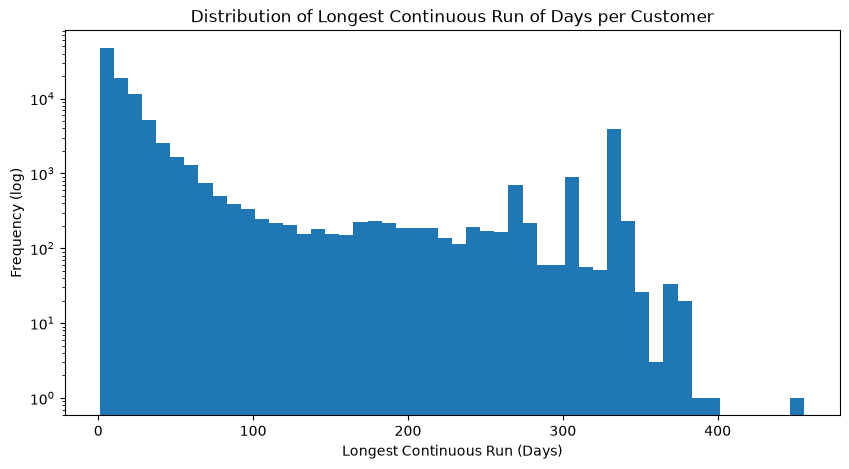

In [38]:
per_customer_runs = per_customer_runs.collect().to_pandas()
per_customer_runs.LONGEST_RUN.plot(kind='hist', bins=50, figsize=(10, 5))
plt.title("Distribution of Longest Continuous Run of Days per Customer")
plt.xlabel("Longest Continuous Run (Days)")
plt.ylabel("Frequency (log)")
plt.yscale('log')
plt.show()

In [39]:
missing_days_threshold = int(0.05*365)
print(f'missing days threshould 5% of 365 is {missing_days_threshold}')

runs = runs.collect().to_pandas()
print(f'number of contiuous runs for all customers {runs.shape[0]}')

runs.head()

missing days threshould 5% of 365 is 18
number of contiuous runs for all customers 4556593


,CUSTOMER_ID,RUN_ID,RUN_START,RUN_END,RUN_LENGTH
0,38214,48,2015-08-05,2015-08-05,1
1,83647,25,2015-05-20,2015-05-20,1
2,96592,21,2015-05-06,2015-05-06,1
3,79837,24,2015-06-04,2015-06-04,1
4,92599,7,2014-12-01,2014-12-02,2


In [40]:
print(f'Number of runs of atleast {365-missing_days_threshold} continuous days: {runs[runs["RUN_LENGTH"] >= 365-missing_days_threshold].shape[0]} runs')

Number of runs of atleast 347 continuous days: 85 runs


In [41]:
print(f'Number of distinct customers satisfying the above condition: {runs[runs["RUN_LENGTH"] >= 365-missing_days_threshold]['CUSTOMER_ID'].nunique()} customers')

Number of distinct customers satisfying the above condition: 85 customers


In [42]:
print(f'Number of customers with incomplete continuous data of atmost 18 days: {runs[(runs["RUN_LENGTH"] >= 365-missing_days_threshold)&(runs["RUN_LENGTH"] <365)].shape[0]} customers')

Number of customers with incomplete continuous data of atmost 18 days: 29 customers


In [43]:
print(f'Number of customers with complete continuous data of atleast 365 days: {runs[runs["RUN_LENGTH"] >= 365].shape[0]} customers')

Number of customers with complete continuous data of atleast 365 days: 56 customers


In [44]:
print(f'Number of runs with complete continuous data of atleast 335 days: {runs[runs["RUN_LENGTH"] >= 335].shape[0]} runs')

Number of runs with complete continuous data of atleast 335 days: 1805 runs


In [45]:
print(f'Number of customers with complete continuous data of atleast 335 days: {runs[runs["RUN_LENGTH"] >= 335]['CUSTOMER_ID'].nunique()} customers')

Number of customers with complete continuous data of atleast 335 days: 1805 customers


In [46]:
runs[runs["RUN_LENGTH"] >= 365].sort_values(by='RUN_LENGTH', ascending=False).head()

,CUSTOMER_ID,RUN_ID,RUN_START,RUN_END,RUN_LENGTH
3936298,64797,1,2014-07-02,2015-09-30,456
4078763,64952,1,2014-09-02,2015-09-30,394
3502153,65169,1,2014-09-23,2015-10-14,387
129072,65395,1,2014-09-26,2015-10-12,382
4167813,65504,1,2014-09-26,2015-10-12,382


`Conclusion`: 
- There is a total of 56 customers with consecutive data of more than or equal to a year (365 days)
- There are 29 customers with continuous data of almost a year (missing atmost 18 days which is 5% of the total number of days in a year)
- So there is a total of 89 customers of timeseries data we could work with (after interpolating incomplete continuous data of customers)
- We could increase the missing_days threshold to increase the total number of customers we work with. For instance a missing days threshold = 30 (1 month) gets us a total of 1805 customers with atleast 335 continuous days of data.

## Geographical Analysis of customers with timeseries data of atleast 335 days

In [47]:
MISSING_DAYS_THRESHOLD = 30
MIN_RUN = 365 - MISSING_DAYS_THRESHOLD   # 335

good_runs = pl.from_pandas(
    runs[runs["RUN_LENGTH"] >= MIN_RUN][["CUSTOMER_ID", "RUN_START", "RUN_END"]]
).with_columns(pl.col("RUN_START").cast(pl.Date), pl.col("RUN_END").cast(pl.Date))

A_continuous = (
    A.join(good_runs.lazy(), on="CUSTOMER_ID")
     .filter(pl.col("DATE").is_between(pl.col("RUN_START"), pl.col("RUN_END")))
)

In [48]:
A_continuous.select(pl.len()).collect().item()

609527

In [49]:
A_continuous.select(pl.col("MUNICIPALITY").n_unique()).collect()

MUNICIPALITY
u32
160


In [50]:
MUNIS = A_continuous.select(pl.col("MUNICIPALITY").unique()).collect().to_series()

In [51]:
munis.filter(pl.col("DE_MUNICIP_org").is_in(list(MUNIS))).select("DE_MUNICIP_org").shape

(160, 1)

In [52]:
munis.collect_schema().names()

['',
 'DE_MUNICIP_org',
 'INE5',
 'latitude',
 'longitude',
 'altitude',
 'CODNUT2',
 'ccaa',
 'Province_code',
 'Province',
 'Municipality',
 'Year',
 'to_coast_km',
 'to_mad_km',
 'to_prov_cap_km',
 'ruggedness',
 'area',
 'pp',
 't_average',
 'spei',
 'grow_period_pp',
 'frost_days',
 'dry_hot_climate',
 'dry_cold_climate',
 'oceanic',
 'mediterranean',
 'mediterranean_fresh_summer',
 'humid_hot',
 'continental_fresh_summer',
 'continental_boreal',
 'climate_zone_cluster']

In [53]:
A_spatial = (
    A_continuous
    .join(
        filtered_munis.lazy(),                  
        left_on="MUNICIPALITY",
        right_on="DE_MUNICIP_org",
        how="inner",
        suffix="_muni",
    )
)
A_spatial.head().collect()

CUSTOMER_ID,DATE,ACTIVE_H1,REACTIVE_H1,ACTIVE_H2,REACTIVE_H2,ACTIVE_H3,REACTIVE_H3,ACTIVE_H4,REACTIVE_H4,ACTIVE_H5,REACTIVE_H5,ACTIVE_H6,REACTIVE_H6,ACTIVE_H7,REACTIVE_H7,ACTIVE_H8,REACTIVE_H8,ACTIVE_H9,REACTIVE_H9,ACTIVE_H10,REACTIVE_H10,ACTIVE_H11,REACTIVE_H11,ACTIVE_H12,REACTIVE_H12,ACTIVE_H13,REACTIVE_H13,ACTIVE_H14,REACTIVE_H14,ACTIVE_H15,REACTIVE_H15,ACTIVE_H16,REACTIVE_H16,ACTIVE_H17,REACTIVE_H17,ACTIVE_H18,…,DAILY_REACTIVE_CONSUMPTION,APPARENT_ENERGY,POWER_FACTOR,REG_QUARTER,REG_YEAR,RUN_START,RUN_END,,INE5,latitude,longitude,altitude,CODNUT2,ccaa,Province_code,Province,Municipality,Year,to_coast_km,to_mad_km,to_prov_cap_km,ruggedness,area,pp,t_average,spei,grow_period_pp,frost_days,dry_hot_climate,dry_cold_climate,oceanic,mediterranean,mediterranean_fresh_summer,humid_hot,continental_fresh_summer,continental_boreal,climate_zone_cluster
i64,date,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,…,i64,f64,f64,i8,i16,date,date,i64,i64,f64,f64,f64,str,str,f64,str,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
95383,2015-01-12,14781,0,12044,0,10599,0,9956,0,9693,0,9832,0,11427,0,15569,0,19090,0,21609,0,24048,0,24703,0,24966,0,25093,0,23542,0,22146,0,22334,0,23936,…,0,481562.0,1.0,1,1991,2014-11-07,2015-10-13,87,23010,38.095993,-3.77484,348.0,"""ES61""","""Andalucía""",23.0,"""Jaen""","""Bailén""","""2010s""",148.8812,256.80377,36.530083,37.629376,117.101,373.710005,16.475834,-0.560763,166.440002,37.513999,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
95383,2014-11-11,15468,0,10503,0,7167,0,6746,0,6759,0,7189,0,7197,0,12650,0,15510,0,14659,0,15108,0,15974,0,18977,0,21110,0,21487,0,20652,0,20162,0,21300,…,0,419766.0,1.0,1,1991,2014-11-07,2015-10-13,87,23010,38.095993,-3.77484,348.0,"""ES61""","""Andalucía""",23.0,"""Jaen""","""Bailén""","""2010s""",148.8812,256.80377,36.530083,37.629376,117.101,373.710005,16.475834,-0.560763,166.440002,37.513999,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
95383,2015-02-09,10756,0,8531,0,7556,0,7050,0,6904,0,7088,0,8263,0,11547,0,14502,0,16332,0,18285,0,18656,0,18970,0,19067,0,17859,0,16863,0,17010,0,17984,…,0,358538.0,1.0,1,1991,2014-11-07,2015-10-13,87,23010,38.095993,-3.77484,348.0,"""ES61""","""Andalucía""",23.0,"""Jaen""","""Bailén""","""2010s""",148.8812,256.80377,36.530083,37.629376,117.101,373.710005,16.475834,-0.560763,166.440002,37.513999,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
36490,2015-05-03,11863,0,9894,0,8536,0,7810,0,7486,0,7483,0,7725,0,8144,0,9716,0,12196,0,14271,0,15104,0,15437,0,16034,0,15689,0,13751,0,12861,0,12628,…,0,296819.0,1.0,1,2001,2014-11-11,2015-10-13,56,29015,37.019443,-4.562459,512.0,"""ES61""","""Andalucía""",29.0,"""Málaga""","""Antequera""","""2010s""",35.191826,384.2084,34.762295,191.938377,816.57599,408.872506,17.176042,-0.550237,163.307503,19.46575,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
45977,2015-08-23,22559,0,21280,0,20386,0,20092,0,19775,0,19460,0,18989,0,11368,0,7728,0,8769,0,9751,0,10259,0,10292,0,3916,0,3908,0,3672,0,3518,0,3463,…,0,271642.0,1.0,3,1989,2014-11-14,2015-10-15,312,21041,37.256536,-6.949574,8.0,"""ES61""","""Andalucía""",21.0,"""Huelva""","""Huelva""","""2010s""",0.96892,449.92264,0.184924,13.286565,152.01601,434.550007,18.805834,-0.394144,157.005002,4.3965,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0


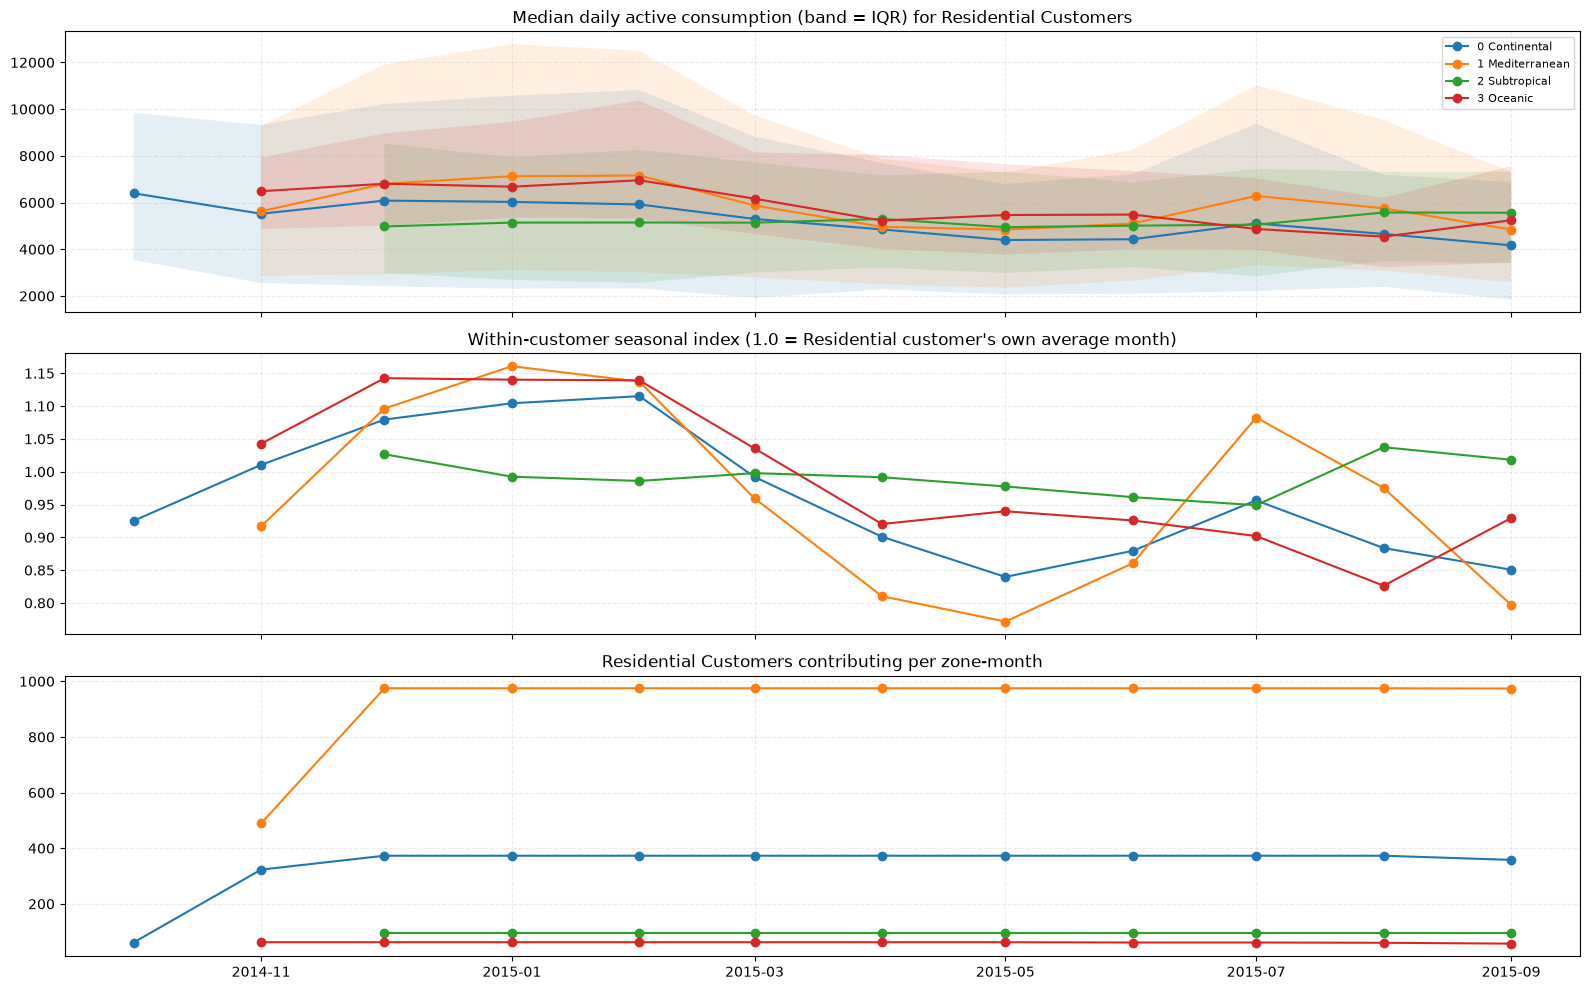

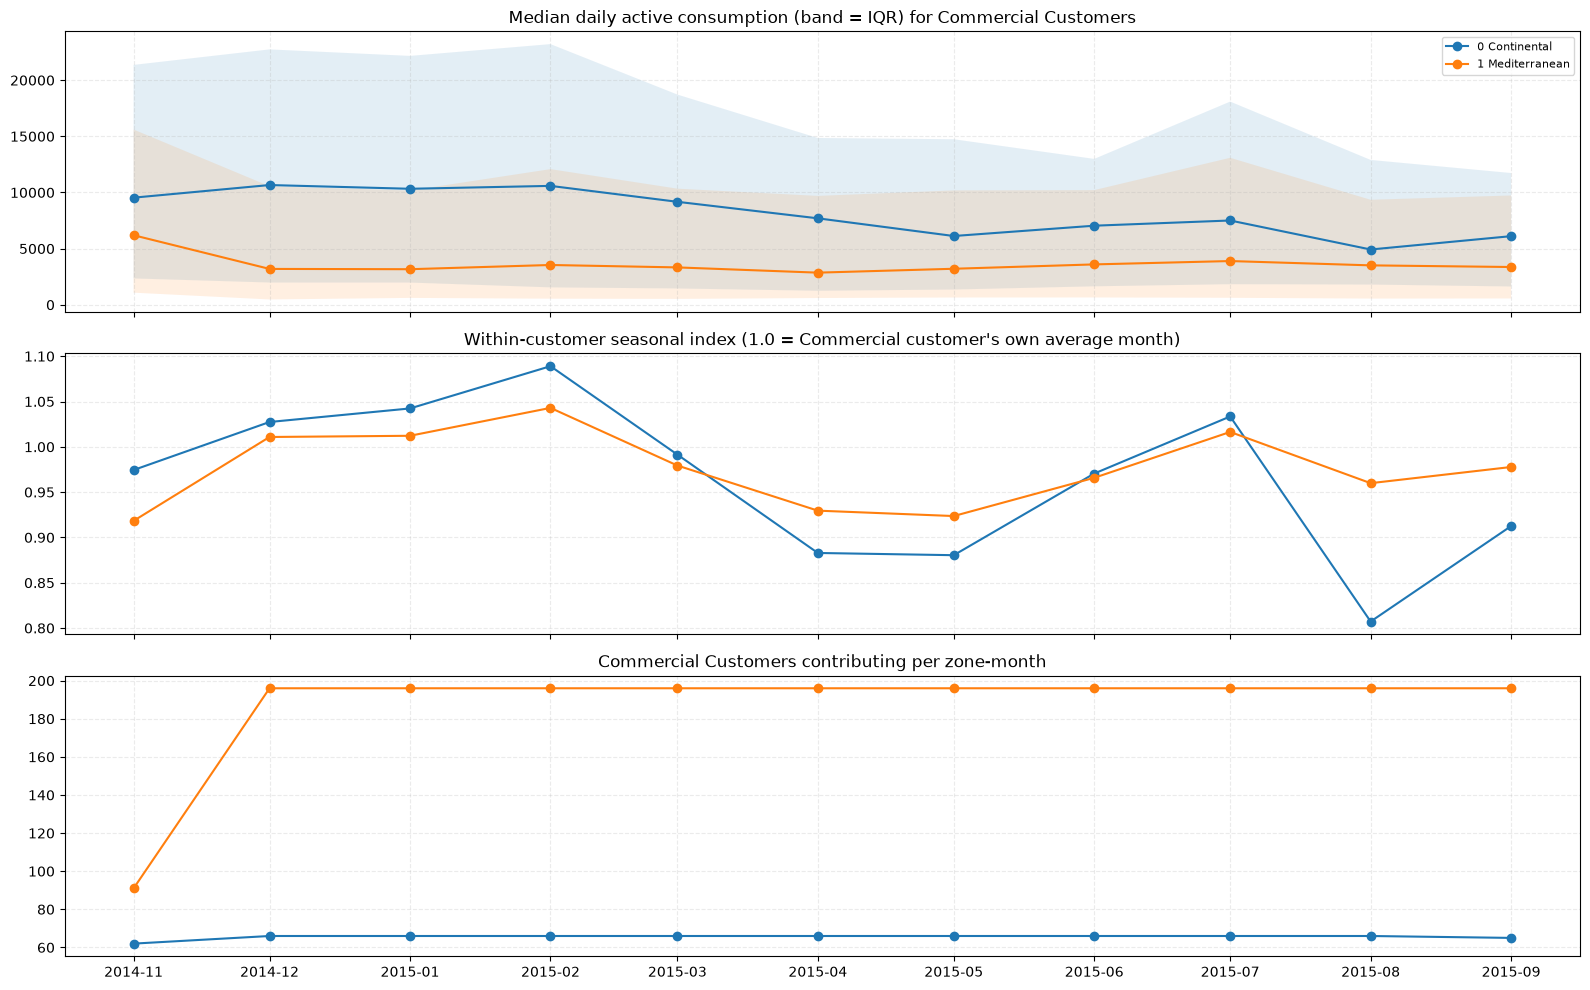

In [58]:
cont_cust_zone = zone_month_table(A_spatial, filtered_munis, by_type=True)

CUSTOMER_TYPE = {
    'T1':'Residential',
    'T2':'Commercial'
}

def plot_zone_customer_number(pdf, customer_type="T1"):
    fig, ax = plt.subplots(3, 1, figsize=(16, 10), sharex=True)
    pdf = pdf[pdf.CUSTOMER_TYPE == customer_type]
    for z, g in pdf.groupby("climate_zone_cluster"):
        lab = ZONE_NAMES.get(int(z), str(z))
        ax[0].plot(g.MONTH, g.MEDIAN, marker="o", label=lab)
        ax[0].fill_between(g.MONTH, g.Q25, g.Q75, alpha=0.12)
        ax[1].plot(g.MONTH, g.MEDIAN_INDEX, marker="o", label=lab)
        ax[2].plot(g.MONTH, g.N_CUSTOMERS, marker="o", label=lab)
    ax[0].set_title(f"Median daily active consumption (band = IQR) for {CUSTOMER_TYPE.get(customer_type)} Customers")
    ax[1].set_title(f"Within-customer seasonal index (1.0 = {CUSTOMER_TYPE.get(customer_type)} customer's own average month)")
    ax[2].set_title(f"{CUSTOMER_TYPE.get(customer_type)} Customers contributing per zone-month")
    ax[0].legend(fontsize=8)
    for a in ax: a.grid(alpha=.25, ls="--")
    plt.tight_layout(); plt.show()


pdf = cont_cust_zone.to_pandas()
plot_zone_customer_number(pdf, customer_type="T1")
plot_zone_customer_number(pdf, customer_type="T2")

In [ ]:
import plotly.express as px

fig = px.scatter_map(
    A_spatial.collect(),
    lat="latitude",
    lon="longitude",
    hover_name="MUNICIPALITY",
    hover_data=["Province", "altitude", "to_coast_km", "area"],
    color="climate_zone_cluster",
    zoom=4.5,
    height=700,
    map_style="carto-voyager", # or open-street-map
)
fig.update_traces(marker=dict(size=6, opacity=0.85))
fig.update_layout(margin=dict(l=0, r=0, t=0, b=0))
fig.show()

Rethinking requirement is recommended in this case to retain data rows

## Exporting cleaned data

In [59]:
list(zip(A.collect_schema().names(), A.collect_schema().dtypes()))

[('CUSTOMER_ID', Int64),
 ('DATE', Date),
 ('ACTIVE_H1', Int32),
 ('REACTIVE_H1', Int32),
 ('ACTIVE_H2', Int32),
 ('REACTIVE_H2', Int32),
 ('ACTIVE_H3', Int32),
 ('REACTIVE_H3', Int32),
 ('ACTIVE_H4', Int32),
 ('REACTIVE_H4', Int32),
 ('ACTIVE_H5', Int32),
 ('REACTIVE_H5', Int32),
 ('ACTIVE_H6', Int32),
 ('REACTIVE_H6', Int32),
 ('ACTIVE_H7', Int32),
 ('REACTIVE_H7', Int32),
 ('ACTIVE_H8', Int32),
 ('REACTIVE_H8', Int32),
 ('ACTIVE_H9', Int32),
 ('REACTIVE_H9', Int32),
 ('ACTIVE_H10', Int32),
 ('REACTIVE_H10', Int32),
 ('ACTIVE_H11', Int32),
 ('REACTIVE_H11', Int32),
 ('ACTIVE_H12', Int32),
 ('REACTIVE_H12', Int32),
 ('ACTIVE_H13', Int32),
 ('REACTIVE_H13', Int32),
 ('ACTIVE_H14', Int32),
 ('REACTIVE_H14', Int32),
 ('ACTIVE_H15', Int32),
 ('REACTIVE_H15', Int32),
 ('ACTIVE_H16', Int32),
 ('REACTIVE_H16', Int32),
 ('ACTIVE_H17', Int32),
 ('REACTIVE_H17', Int32),
 ('ACTIVE_H18', Int32),
 ('REACTIVE_H18', Int32),
 ('ACTIVE_H19', Int32),
 ('REACTIVE_H19', Int32),
 ('ACTIVE_H20', Int32),
 (

In [60]:
A.select(pl.len()).collect().item()

15984952

In [46]:
(
    A
    .sink_parquet(
        PROJECT_ROOT / "data" / "A_analysis.parquet",
        compression="zstd",
        row_group_size=500_000,
    )
)